# Libraries, themes

In [2]:
rm(list=ls())

ReqdLibs = c("repr","ggplot2","IRdisplay","ggpubr","patchwork","dplyr","tidyr","boot","purrr",
             "lubridate","performance","lemon","robustlmm","broom","influence.ME",
             "sjstats","sjPlot","lme4","plotly","ggExtra","ggthemes","ggstance","car",
             "grid","svglite","viridis","patchwork","forcats","emmeans")
invisible(lapply(ReqdLibs, library, character.only = TRUE)) 

thm = theme(
          strip.text.x=element_text(size=16,face="bold"),
          strip.text.y=element_text(size=16),
          legend.text=element_text(size=16,face="bold"),
          legend.position = "right",
          legend.title=element_text(size=16,face="bold"),
          title =element_text(size=14, face='bold'),
          text = element_text(colour = "black",size=18), 
          plot.title = element_text(colour = "black",size = 16, face = "bold"),
          axis.ticks.length = unit(0.4,"cm"),
          axis.line = element_line(colour = "black",linewidth=0.75),
          axis.ticks = element_line(colour = "black",linewidth=0.75),
          axis.text = element_text(colour = "black",size=20),
          axis.title=element_text(size=16)) 

# Data, definitions

## Define subj IDs for adding identifiers

In [3]:
dat = read.csv("VR-Adults-Data.csv", stringsAsFactors = FALSE)

# subj identifiers for bimanual-wide group
v2_2 = c("MUH278","MUH279","MUH280","MUH281","MUH117","MUH235","MUH296","MUH302","MUH301","MUH294","MUH295","MUH298",
         "MUH293","MUH260","MUH220","MUH346","MUH259","MUH226","MUH227","MUH117","MUH235","MUH298","MUH1048")

# subj identifiers for unimanual-narrow group
v3 = c("MUH537","MUH584","MUH643","MUH631","MUH536","MUH598","MUH00U","MUH535","MUH617","MUH644",
       "MUH683","MUH684","MUH616","MUH750","MUH822","MUH749","MUH819","MUH821","MUH825","MUH832","MUH833")

# trial identifiers for splitting adaptation phase
rampUpT = c(51:125)

# rename learning phase (cond) levels
dat$cond = factor(dat$cond, levels=c('baseline','adaptation','washout'))

# remove NA trials for later calculating reward rates accurately
dat %>% filter() %>% mutate(reward = ifelse(is.na(Ry), NA,reward)) -> dat

# check-see
dim(dat)
head(dat)

[1] 14383    81

,grp,subj,cond,trial,gain,reward,Ry,sRy,Ly,sLy,⋯,latenciesP_1,latenciesP_2,latenciesP_3,latenciesP_4,latenciesP_5,latenciesP_6,latenciesP_7,latenciesP_8,latenciesP_9,latenciesP_10
,<chr>,<chr>,<fct>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,adults,MUH000,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,0.07068500,0.10995444,0.1426790,0.1747490,0.2107460,0.2506700,0.2977933,0.3534250,0.4228010,0.6538363
2,adults,MUH000,baseline,2,1,1,0.3240338,0.3240338,0.3158020,0.3158020,⋯,0.11177606,0.15099573,0.1869471,0.2242058,0.2640791,0.3032988,0.3457868,0.3967723,0.4673677,0.6530075
3,adults,MUH000,baseline,3,1,1,0.3185680,0.3185680,0.3316496,0.3316496,⋯,0.10174501,0.14520890,0.1876850,0.2351001,0.2874544,0.3388208,0.3971019,0.4771150,0.6282508,0.9868278
4,adults,MUH000,baseline,4,1,1,0.3055809,0.3055809,0.3165627,0.3165627,⋯,0.05713485,0.09754731,0.1351727,0.1714046,0.2132105,0.2578036,0.3079708,0.3678927,0.4466273,0.6960697
5,adults,MUH000,baseline,5,1,1,0.2953125,0.2953125,0.3054349,0.3054349,⋯,0.07086945,0.11516286,0.1533233,0.1914838,0.2303257,0.2718934,0.3161868,0.3747904,0.4531556,0.6807556
6,adults,MUH000,baseline,6,1,1,0.3163733,0.3163733,0.3305105,0.3305105,⋯,0.09648401,0.13772908,0.1767646,0.2202192,0.2629373,0.3063920,0.3535292,0.4124507,0.4890487,0.7357826


## Add identifiers & calculate some new measures

In [4]:
dat %>%  
filter(!Py <0.2) %>% 
mutate(tgtHt = ifelse(subj%in%v2_2,"6","3"),
       tgtHtC = ifelse(subj%in%v2_2,"wide","narrow"),
       expGrp=ifelse(subj%in%v3,"unimanual","bimanual"),
       
       cond2 = ifelse(trial%in%rampUpT,"rampUp",as.character(cond)),
       gainF = 1/gain, # inverse of gain

       totDispR = Ry + (Py -sRy),
       totDispL = Ly + (Py -sLy),
       
       EarlySlopeAdj = ifelse(subj%in%v3,slopesR_2, slopesR_2/slopesL_2),
       LateSlopeAdj = ifelse(subj%in%v3,slopesR_10, slopesR_10/slopesL_10)) -> dat2

dat2$ID <- seq_along(dat2[,1])

# relevel so reference is 3, narrow, and baseline
dat2$cond2 = factor(dat2$cond2, levels=c('baseline','rampUp','adaptation','washout'),
                                labels = c("baseline","rampUp","plateau","washout"))
dat2$expGrp = factor(dat2$expGrp,levels=c('unimanual','bimanual'))
dat2$tgtHtC = factor(dat2$tgtHt,levels=c('3','6'),labels = c('narrow','wide'))

#check-see
dim(dat2)
head(dat2)

[1] 14379    91

,grp,subj,cond,trial,gain,reward,Ry,sRy,Ly,sLy,⋯,tgtHt,tgtHtC,expGrp,cond2,gainF,totDispR,totDispL,EarlySlopeAdj,LateSlopeAdj,ID
,<chr>,<chr>,<fct>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,adults,MUH000,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,3,narrow,bimanual,baseline,1,0.3077876,0.3077876,1.0339469,1.0150046,1
2,adults,MUH000,baseline,2,1,1,0.3240338,0.3240338,0.3158020,0.3158020,⋯,3,narrow,bimanual,baseline,1,0.2906669,0.2906669,0.9911115,1.0260663,2
3,adults,MUH000,baseline,3,1,1,0.3185680,0.3185680,0.3316496,0.3316496,⋯,3,narrow,bimanual,baseline,1,0.3005657,0.3005657,1.0034200,0.9605560,3
4,adults,MUH000,baseline,4,1,1,0.3055809,0.3055809,0.3165627,0.3165627,⋯,3,narrow,bimanual,baseline,1,0.2985514,0.2985514,1.0333849,0.9653093,4
5,adults,MUH000,baseline,5,1,1,0.2953125,0.2953125,0.3054349,0.3054349,⋯,3,narrow,bimanual,baseline,1,0.2922828,0.2922828,1.0885727,0.9668593,5
6,adults,MUH000,baseline,6,1,1,0.3163733,0.3163733,0.3305105,0.3305105,⋯,3,narrow,bimanual,baseline,1,0.2918796,0.2918796,1.1233890,0.9572261,6


# Normalize to baseline

## add '_raw' suffix to help with calc

In [5]:
options(warn=-1)
idCols = c("grp","expGrp","ID","tgtHt","tgtHtC","subj","cond","cond2","trial","gain","gainF","reward")
dat2 %>% 
rename_with(.fn = function(.x){paste0(.x,"_raw")},.cols=-idCols) -> dat2b

#check-see
dim(dat2b)
head(dat2b)

[1] 14379    91

,grp,subj,cond,trial,gain,reward,Ry_raw,sRy_raw,Ly_raw,sLy_raw,⋯,tgtHt,tgtHtC,expGrp,cond2,gainF,totDispR_raw,totDispL_raw,EarlySlopeAdj_raw,LateSlopeAdj_raw,ID
,<chr>,<chr>,<fct>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,adults,MUH000,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,3,narrow,bimanual,baseline,1,0.3077876,0.3077876,1.0339469,1.0150046,1
2,adults,MUH000,baseline,2,1,1,0.3240338,0.3240338,0.3158020,0.3158020,⋯,3,narrow,bimanual,baseline,1,0.2906669,0.2906669,0.9911115,1.0260663,2
3,adults,MUH000,baseline,3,1,1,0.3185680,0.3185680,0.3316496,0.3316496,⋯,3,narrow,bimanual,baseline,1,0.3005657,0.3005657,1.0034200,0.9605560,3
4,adults,MUH000,baseline,4,1,1,0.3055809,0.3055809,0.3165627,0.3165627,⋯,3,narrow,bimanual,baseline,1,0.2985514,0.2985514,1.0333849,0.9653093,4
5,adults,MUH000,baseline,5,1,1,0.2953125,0.2953125,0.3054349,0.3054349,⋯,3,narrow,bimanual,baseline,1,0.2922828,0.2922828,1.0885727,0.9668593,5
6,adults,MUH000,baseline,6,1,1,0.3163733,0.3163733,0.3305105,0.3305105,⋯,3,narrow,bimanual,baseline,1,0.2918796,0.2918796,1.1233890,0.9572261,6


## extract baseline & average

In [6]:
dat2b %>% 
filter(cond=="baseline") %>% 
select(!gain & !gainF) %>% 
group_by(grp,expGrp,subj,tgtHt) %>% 
do(tail(., 10)) %>% 
mutate_if(is.double, list(blCorr = mean), na.rm = TRUE) -> blCorrEP

head(blCorrEP)

`mutate_if()` ignored the following grouping variables:
• Columns `grp`, `expGrp`, `subj`, `tgtHt`


grp,subj,cond,trial,reward,Ry_raw,sRy_raw,Ly_raw,sLy_raw,Py_raw,⋯,latenciesP_5_raw_blCorr,latenciesP_6_raw_blCorr,latenciesP_7_raw_blCorr,latenciesP_8_raw_blCorr,latenciesP_9_raw_blCorr,latenciesP_10_raw_blCorr,totDispR_raw_blCorr,totDispL_raw_blCorr,EarlySlopeAdj_raw_blCorr,LateSlopeAdj_raw_blCorr
<chr>,<chr>,<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
adults,MUH00U,baseline,41,1,0.3116160,0.3116160,-8.44e-15,-8.44e-15,0.2933347,⋯,0.1521072,0.1811604,0.2128989,0.2493718,0.2960654,0.3912193,0.2934564,0.2934564,1.251982,0.8018431
adults,MUH00U,baseline,42,1,0.2942757,0.2942757,4.71e-14,4.71e-14,0.2832265,⋯,0.1521072,0.1811604,0.2128989,0.2493718,0.2960654,0.3912193,0.2934564,0.2934564,1.251982,0.8018431
adults,MUH00U,baseline,43,1,0.2917019,0.2917019,-5.24e-14,-5.24e-14,0.2839426,⋯,0.1521072,0.1811604,0.2128989,0.2493718,0.2960654,0.3912193,0.2934564,0.2934564,1.251982,0.8018431
adults,MUH00U,baseline,44,1,0.2967440,0.2967440,2.30e-13,2.30e-13,0.2719899,⋯,0.1521072,0.1811604,0.2128989,0.2493718,0.2960654,0.3912193,0.2934564,0.2934564,1.251982,0.8018431
adults,MUH00U,baseline,45,1,0.3099028,0.3099028,1.82e-14,1.82e-14,0.3077380,⋯,0.1521072,0.1811604,0.2128989,0.2493718,0.2960654,0.3912193,0.2934564,0.2934564,1.251982,0.8018431
adults,MUH00U,baseline,46,1,0.3126511,0.3126511,1.91e-14,1.91e-14,0.2982242,⋯,0.1521072,0.1811604,0.2128989,0.2493718,0.2960654,0.3912193,0.2934564,0.2934564,1.251982,0.8018431


## combine with parent df

In [7]:
dat2c = left_join(dat2b,blCorrEP,by=c('subj'='subj'), suffix=c("",".y"))
head(dat2c)

,grp,subj,cond,trial,gain,reward,Ry_raw,sRy_raw,Ly_raw,sLy_raw,⋯,latenciesP_5_raw_blCorr,latenciesP_6_raw_blCorr,latenciesP_7_raw_blCorr,latenciesP_8_raw_blCorr,latenciesP_9_raw_blCorr,latenciesP_10_raw_blCorr,totDispR_raw_blCorr,totDispL_raw_blCorr,EarlySlopeAdj_raw_blCorr,LateSlopeAdj_raw_blCorr
,<chr>,<chr>,<fct>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,adults,MUH000,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,0.2096147,0.250092,0.2951953,0.3475689,0.4187486,0.6379272,0.299333,0.299333,1.034735,1.020246
2,adults,MUH000,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,0.2096147,0.250092,0.2951953,0.3475689,0.4187486,0.6379272,0.299333,0.299333,1.034735,1.020246
3,adults,MUH000,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,0.2096147,0.250092,0.2951953,0.3475689,0.4187486,0.6379272,0.299333,0.299333,1.034735,1.020246
4,adults,MUH000,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,0.2096147,0.250092,0.2951953,0.3475689,0.4187486,0.6379272,0.299333,0.299333,1.034735,1.020246
5,adults,MUH000,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,0.2096147,0.250092,0.2951953,0.3475689,0.4187486,0.6379272,0.299333,0.299333,1.034735,1.020246
6,adults,MUH000,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,0.2096147,0.250092,0.2951953,0.3475689,0.4187486,0.6379272,0.299333,0.299333,1.034735,1.020246


## normalize to baseline (`_raw_blCorr`)

In [8]:
dat2c %>% 
select(-ends_with(".y"))  %>% 
mutate(across(ends_with("_raw"), .names = "{sub('raw', 'corr', col)}") 
       / across(ends_with("_raw_blCorr"))) %>% 
select(-ends_with("raw_blCorr")) %>%  
mutate(endTilt = (Ry_raw/Ly_raw)) %>%
distinct(ID, .keep_all =TRUE) -> dat3

#check-see
dim(dat3)
head(dat3)

[1] 14379   171

,grp,subj,cond,trial,gain,reward,Ry_raw,sRy_raw,Ly_raw,sLy_raw,⋯,latenciesP_6_corr,latenciesP_7_corr,latenciesP_8_corr,latenciesP_9_corr,latenciesP_10_corr,totDispR_corr,totDispL_corr,EarlySlopeAdj_corr,LateSlopeAdj_corr,endTilt
,<chr>,<chr>,<fct>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,adults,MUH000,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,1.002311,1.008801,1.016849,1.009677,1.024939,1.0282447,1.0282447,0.9992385,0.9948622,1.0150046
2,adults,MUH000,baseline,2,1,1,0.3240338,0.3240338,0.3158020,0.3158020,⋯,1.212749,1.171383,1.141565,1.116106,1.023639,0.9710485,0.9710485,0.9578410,1.0057045,1.0260663
3,adults,MUH000,baseline,3,1,1,0.3185680,0.3185680,0.3316496,0.3316496,⋯,1.354785,1.345217,1.372721,1.500305,1.546929,1.0041181,1.0041181,0.9697364,0.9414941,0.9605560
4,adults,MUH000,baseline,4,1,1,0.3055809,0.3055809,0.3165627,0.3165627,⋯,1.030835,1.043278,1.058474,1.066576,1.091143,0.9973888,0.9973888,0.9986954,0.9461532,0.9653093
5,adults,MUH000,baseline,5,1,1,0.2953125,0.2953125,0.3054349,0.3054349,⋯,1.087174,1.071110,1.078320,1.082166,1.067137,0.9764468,0.9764468,1.0520306,0.9476724,0.9668593
6,adults,MUH000,baseline,6,1,1,0.3163733,0.3163733,0.3305105,0.3305105,⋯,1.225117,1.197611,1.186673,1.167881,1.153396,0.9750998,0.9750998,1.0856782,0.9382304,0.9572261


## rename few vars, remove underscore '_' 

In [9]:
dat3 <- dat3 %>%
  rename_with(~ gsub("slopesR_", "slopesR", .x, fixed = TRUE)) %>%
  rename_with(~ gsub("latenciesR_", "latenciesR", .x, fixed = TRUE)) %>%
  rename_with(~ gsub("slopesL_", "slopesL", .x, fixed = TRUE)) %>%
  rename_with(~ gsub("latenciesL_", "latenciesL", .x, fixed = TRUE)) %>%
  rename_with(~ gsub("slopesP_", "slopesP", .x, fixed = TRUE)) %>%
  rename_with(~ gsub("latenciesP_", "latenciesP", .x, fixed = TRUE)) %>%
  mutate(
    tilt_comp = Py_corr - sRy_corr,  
    onCompR_corr = slopesR10_corr - slopesR2_corr,
    onCompL_corr = slopesL10_corr - slopesL2_corr,
    asymIdx_early = ifelse(subj %in% v3, NaN, (slopesR2_corr - slopesL2_corr) / (slopesR2_corr + slopesL2_corr)),
    asymIdx_late = ifelse(subj %in% v3, NaN, (slopesR10_corr - slopesL10_corr) / (slopesR10_corr + slopesL10_corr))
  ) %>%
  group_by(grp, expGrp, subj, tgtHt, .drop = FALSE) %>%
  mutate(
    lag.reward = lag(reward, 1),
    lag.EarlySlopeAdj_corr = lag(EarlySlopeAdj_corr, 1),
    diff.EarlySlopeAdj = EarlySlopeAdj_corr - lag.EarlySlopeAdj_corr,
    abs.diff.EarlySlopeAdj = abs(diff.EarlySlopeAdj) # Difference is already calculated above
  ) %>%
  ungroup() # Optional if you no longer need grouping for further steps

#check-see
dim(dat3)
head(dat3)

[1] 14379   180

grp,subj,cond,trial,gain,reward,Ry_raw,sRy_raw,Ly_raw,sLy_raw,⋯,endTilt,tilt_comp,onCompR_corr,onCompL_corr,asymIdx_early,asymIdx_late,lag.reward,lag.EarlySlopeAdj_corr,diff.EarlySlopeAdj,abs.diff.EarlySlopeAdj
<chr>,<chr>,<fct>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
adults,MUH000,baseline,1,1,1,0.3218737,0.3218737,0.3171156,0.3171156,⋯,1.0150046,0.006126254,0.11615856,0.11937669,-0.0009020067,-0.002416917,NA,NA,NA,NA
adults,MUH000,baseline,2,1,1,0.3240338,0.3240338,0.3158020,0.3158020,⋯,1.0260663,-0.057929168,0.36182688,0.32718145,-0.0220542674,0.003002715,1,0.9992385,-0.04139748,0.04139748
adults,MUH000,baseline,3,1,1,0.3185680,0.3185680,0.3316496,0.3316496,⋯,0.9605560,-0.007502865,-0.09111056,-0.07489378,-0.0158853024,-0.029976014,1,0.9578410,0.01189532,0.01189532
adults,MUH000,baseline,4,1,1,0.3055809,0.3055809,0.3165627,0.3165627,⋯,0.9653093,0.027008705,-0.17791566,-0.13047783,-0.0011738484,-0.027509871,1,0.9697364,0.02895903,0.02895903
adults,MUH000,baseline,5,1,1,0.2953125,0.2953125,0.3054349,0.3054349,⋯,0.9668593,0.038674199,0.01845454,0.10768667,0.0248348801,-0.026708278,1,0.9986954,0.05333522,0.05333522
adults,MUH000,baseline,6,1,1,0.3163733,0.3163733,0.3305105,0.3305105,⋯,0.9572261,-0.029551831,0.06134765,0.18056547,0.0405590394,-0.031710650,1,1.0520306,0.03364757,0.03364757


# Summarize
**reduce to only required trials**
* end of baseline
* start of training plateau
* end of training plateau
* start of washout

*Note: Every level operates on the dataframe defined in the previous level, so cannot skip steps/code lines*


### Specify various epochs by indicating trial sequence 

In [10]:
bl = seq(from = 41, to = 50, by = 1)
sru = seq(from = 51, to = 75, by = 1)
eru = seq(from = 101, to = 125, by = 1)
sad = seq(from = 126, to = 150, by = 1)
ead = seq(from = 176, to = 200, by = 1)
swo = seq(from = 201, to = 205, by = 1)
ewo = seq(from = 250, to = 260, by = 1)

## SummDat
Simply extracting the end of baseline, end of adaptation, and start of washout from dat3.<br>
**Individual trials is preserved**

In [11]:
dat3 %>%
  select(!gainF) %>%
  group_by(grp, expGrp, subj, cond2, tgtHt) %>%
  mutate(
    cond3 = case_when(
      trial %in% bl ~ "baseline",
      trial %in% sru ~ "start.ramp",
      trial %in% eru ~ "end.ramp",
      trial %in% sad ~ "start.plateau",
      trial %in% ead ~ "end.plateau",
      trial %in% swo ~ "start.washout",
      trial %in% ewo ~ "end.washout",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(cond3)) -> summDat

# To ensure correct ordering of factor levels for `cond3`
summDat$cond3 <- factor(summDat$cond3,
                        levels = c("baseline", "start.ramp", "end.ramp",
                                   "start.plateau", "end.plateau",
                                   "start.washout", "end.washout"))

# Verify unique values in cond3
unique(summDat$cond3)

# define another OmniGrp (with three levels for Uni-narrow, Bi-narrow and Bi-wide)
# variable for success rate comparisons
summDat = 
summDat %>% 
  mutate(OmniGrp = case_when(
      expGrp == "unimanual" ~ "uni-narrow",  
      expGrp == "bimanual" & tgtHtC == "narrow" ~ "bi-narrow", 
      expGrp == "bimanual" & tgtHtC == "wide" ~ "bi-wide"))

[1] baseline      start.ramp    end.ramp      start.plateau end.plateau  
[6] start.washout end.washout  
7 Levels: baseline start.ramp end.ramp start.plateau ... end.washout

## SummDat2
Summarize trials from SummDat to means **per subject**<br>
Each subject has 3 rows though, 1 per condition (baseline, adaptation, washout)<br>
This is the one used for plotting  groupwise means

In [12]:
summDat %>%
  group_by(grp, expGrp, subj, cond3, tgtHtC) %>%
  summarise(
    totTr = sum(!is.na(reward)),
    succRate = sum(reward == 1, na.rm = TRUE) / totTr * 100,
    across(is.double, list(mn = mean, std = sd), .names = "{.col}_{.fn}"),
    .groups = "keep"  # Correct placement of the `.groups` argument
  ) %>%
  ungroup() -> summDat2

summDat2 = 
summDat2 %>% 
  mutate(OmniGrp = case_when(
      expGrp == "unimanual" ~ "uni-narrow",  
      expGrp == "bimanual" & tgtHtC == "narrow" ~ "bi-narrow", 
      expGrp == "bimanual" & tgtHtC == "wide" ~ "bi-wide"))

head(summDat2,7)

grp,expGrp,subj,cond3,tgtHtC,totTr,succRate,gain_mn,gain_std,Ry_raw_mn,⋯,asymIdx_late_std,lag.EarlySlopeAdj_corr_mn,lag.EarlySlopeAdj_corr_std,diff.EarlySlopeAdj_mn,diff.EarlySlopeAdj_std,abs.diff.EarlySlopeAdj_mn,abs.diff.EarlySlopeAdj_std,succRate_mn,succRate_std,OmniGrp
<chr>,<fct>,<chr>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
adults,unimanual,MUH00U,baseline,narrow,10,100.00000,1.0000000,0.000000000,0.3057436,⋯,NA,0.9889921,0.11854350,0.011007937,0.1579701,0.12505719,0.08781910,100.00000,NA,uni-narrow
adults,unimanual,MUH00U,start.ramp,narrow,22,86.36364,0.9577273,0.033655371,0.3252298,⋯,NA,0.9214663,0.19301571,0.003095488,0.2339243,0.15274549,0.17403574,86.36364,NA,uni-narrow
adults,unimanual,MUH00U,end.ramp,narrow,25,92.00000,0.7256000,0.034650637,0.3896828,⋯,NA,1.0889770,0.20053898,0.022703877,0.2405040,0.19669821,0.13445009,92.00000,NA,uni-narrow
adults,unimanual,MUH00U,start.plateau,narrow,21,100.00000,0.6509524,0.003007926,0.4103943,⋯,NA,1.1673812,0.24298077,0.022407323,0.2666361,0.21729035,0.14847945,100.00000,NA,uni-narrow
adults,unimanual,MUH00U,end.plateau,narrow,25,80.00000,0.6500000,0.000000000,0.4101305,⋯,NA,1.3498322,0.17417090,0.011207003,0.1188535,0.09972496,0.06243019,80.00000,NA,uni-narrow
adults,unimanual,MUH00U,start.washout,narrow,5,20.00000,1.0000000,0.000000000,0.3606305,⋯,NA,1.6223203,0.15262888,-0.072249465,0.3512233,0.30718439,0.10922441,20.00000,NA,uni-narrow
adults,unimanual,MUH00U,end.washout,narrow,11,100.00000,1.0000000,0.000000000,0.3017827,⋯,NA,1.1385297,0.08606071,-0.013432852,0.1416738,0.10551199,0.08957614,100.00000,NA,uni-narrow


# Plots

## Figure 2

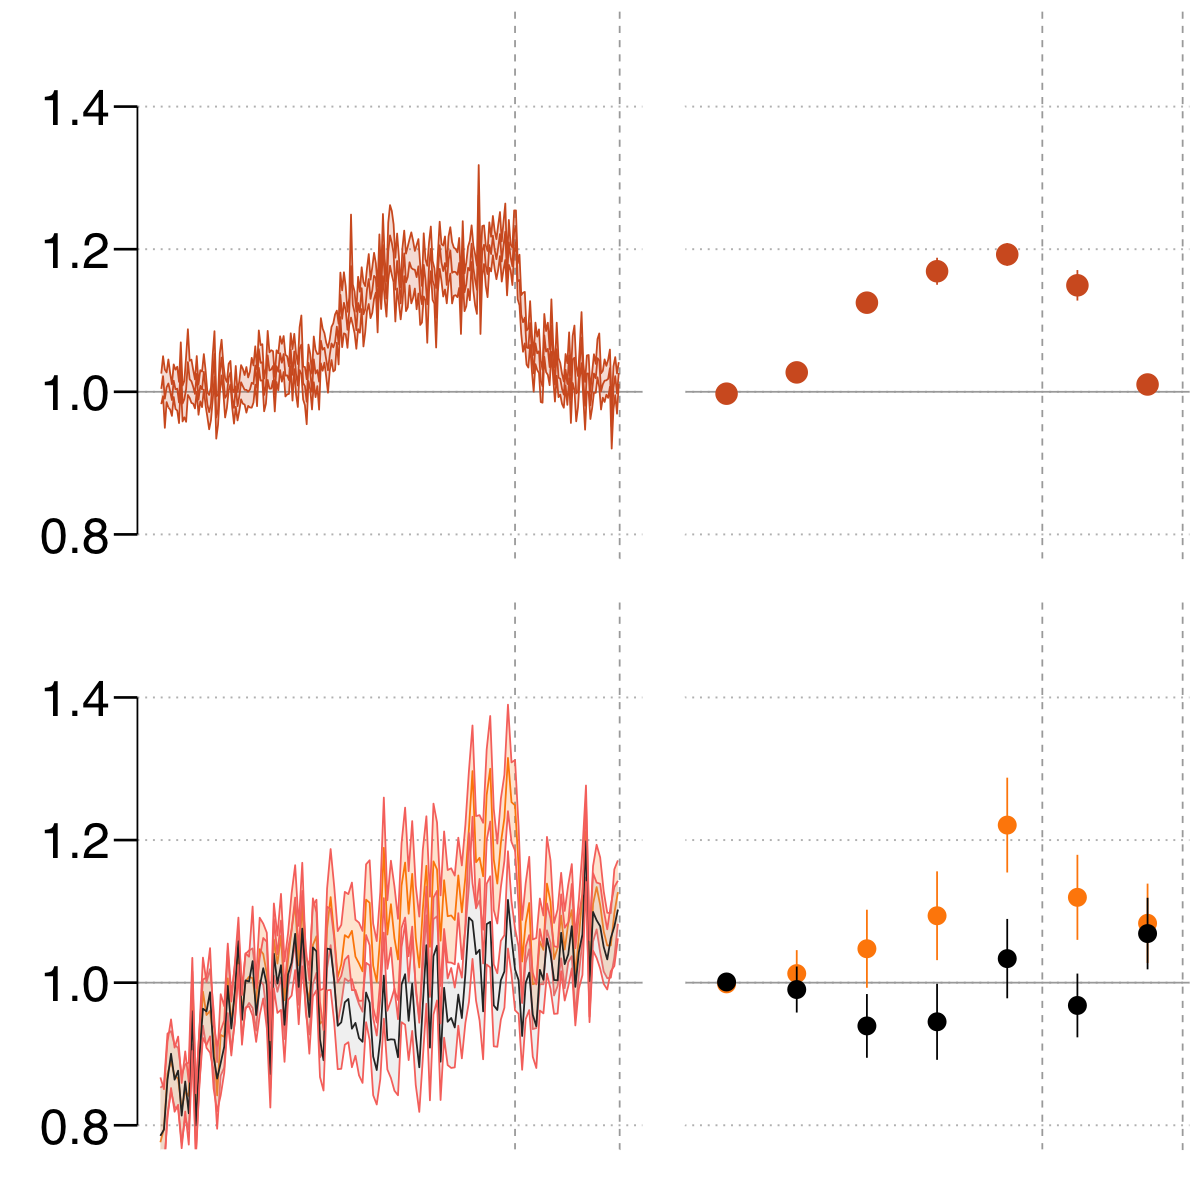

In [13]:
options(repr.plot.width=5, repr.plot.height=5)
bb = 1
#--------------------------------------------------------------------------

Fig2A = ggplot(aes(x = trial,y = EarlySlopeAdj_corr,col=tgtHtC,fill=tgtHtC,group=tgtHtC),
             data = dat3 %>% filter(grp=="adults" & expGrp=="bimanual" & tgtHtC=="narrow")) +
coord_capped_cart(ylim = c(0.8,1.5), xlim = c(1, 260), bottom = 'both', left = 'both') +
geom_vline(xintercept = c(201,260), lty="dashed",col="darkgray") +
geom_hline(yintercept = 1, lty="solid",col="darkgray") +

stat_summary_bin(geom="line",fun.y = mean,
                 binwidth=1,lwd=1.2,alpha=1,show.legend = FALSE) +
stat_summary_bin(geom="ribbon",fun.data = mean_se,
                 binwidth=1,lwd=0,alpha=0.2,show.legend = FALSE) +

xlab("") + ylab("") +
scale_color_manual(values = c("#D35D27")) +
scale_fill_manual(values = c("#D35D27")) +

scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) + 
theme_clean() + thm + theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
      axis.text.y = element_text(size = 30),
      axis.ticks.length.y=unit(0.5,units = "cm"),
      axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "black")
     ) 

#--------------------------------------------------------------------------
Fig2B = ggplot(aes(x = cond3,y = EarlySlopeAdj_corr_mn,col=tgtHtC,fill=tgtHtC,
                          group=tgtHtC),
             data = summDat2 %>% filter(grp=="adults" & expGrp=="bimanual" & tgtHtC=="narrow")) +
coord_capped_cart(ylim = c(0.8,1.5), bottom = 'both', left = 'both') +
geom_vline(xintercept = c(5.5,7.5), lty="dashed",col="darkgray") +
geom_hline(yintercept = 1, lty="solid",col="darkgray") +

stat_summary_bin(geom="pointrange",fun.data = mean_se,
                 binwidth=bb,lwd=1.25,alpha=1,size = 1.25, show.legend = FALSE) +

xlab("") + ylab("") +
scale_color_manual(values = c("#D35D27")) +
scale_fill_manual(values = c("#D35D27")) +
theme_clean() + thm + theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "white"),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank() 
     ) 

#--------------------------------------------------------------------------
bb = 2
Fig2C = ggplot(aes(x = trial,y = slopesR2_corr,col=tgtHtC,fill=tgtHtC,group=tgtHtC),
             data = dat3 %>% filter(grp=="adults" & expGrp=="bimanual" & tgtHtC=="narrow")) +
coord_capped_cart(ylim = c(0.8,1.5), xlim = c(1, 260), bottom = 'both', left = 'both') +
geom_vline(xintercept = c(201,260), lty="dashed",col="darkgray") +
geom_hline(yintercept = 1, lty="solid",col="darkgray") +

# plotting right hand early scaling
stat_summary_bin(geom="line",fun.y = mean, col = "#FF8A04",
                 binwidth=bb,lwd=1.25,alpha=1,show.legend = FALSE) +
stat_summary_bin(geom="ribbon",fun.data = mean_se, fill = "#FF8A04",
                 binwidth=bb,lwd=0,alpha=0.2,show.legend = FALSE) +

# plotting left hand early scaling
stat_summary_bin(aes(y = slopesL2_corr), geom="line",fun.y = mean, col = "black",
                 binwidth=bb,lwd=1.25,alpha=1,show.legend = FALSE) + 
stat_summary_bin(aes(y = slopesL2_corr), geom="ribbon",fun.data = mean_se, fill = "gray",
                 binwidth=bb,lwd=0,alpha=0.2,show.legend = FALSE) +

xlab("") + ylab("") +

# adjust appearance
scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) + 
theme_clean() + thm + theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
      axis.text.y = element_text(size = 30),
      axis.ticks.length.y=unit(0.5,units = "cm"),
      axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "black")
     ) 

#--------------------------------------------------------------------------

Fig2D = ggplot(aes(x = cond3,y = slopesR2_corr_mn,col=tgtHtC,fill=tgtHtC,group=tgtHtC),
             data = summDat2 %>% filter(grp=="adults" & expGrp=="bimanual" & tgtHtC=="narrow")) +
coord_capped_cart(ylim = c(0.8,1.5),bottom = 'both', left = 'both') +
geom_vline(xintercept = c(5.5,7.5), lty="dashed",col="darkgray") +
geom_hline(yintercept = 1, lty="solid",col="darkgray") +

stat_summary_bin(geom="pointrange",fun.data = mean_se, col = "#FF8A04",
                 lwd=1.25,size = 1, alpha=1,show.legend = FALSE) +

stat_summary_bin(aes(y = slopesL2_corr_mn), geom="pointrange",fun.data = mean_se, col = "black",
                 lwd=1.25,size = 1, alpha=1,show.legend = FALSE) + 

xlab("") + ylab("") +

theme_clean() + thm + theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "white"),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank() 
     ) 

#--------------------------------------------------------------------------
#--------------------------------------------------------------------------

options(repr.plot.width=10, repr.plot.height=10)

Fig2 = (Fig2A | Fig2B) / (Fig2C | Fig2D)
Fig2

# ggsave(file="Fig2_final_v3.svg", bg = "transparent", plot=Fig2, width=10, height=10)


## Figure 3

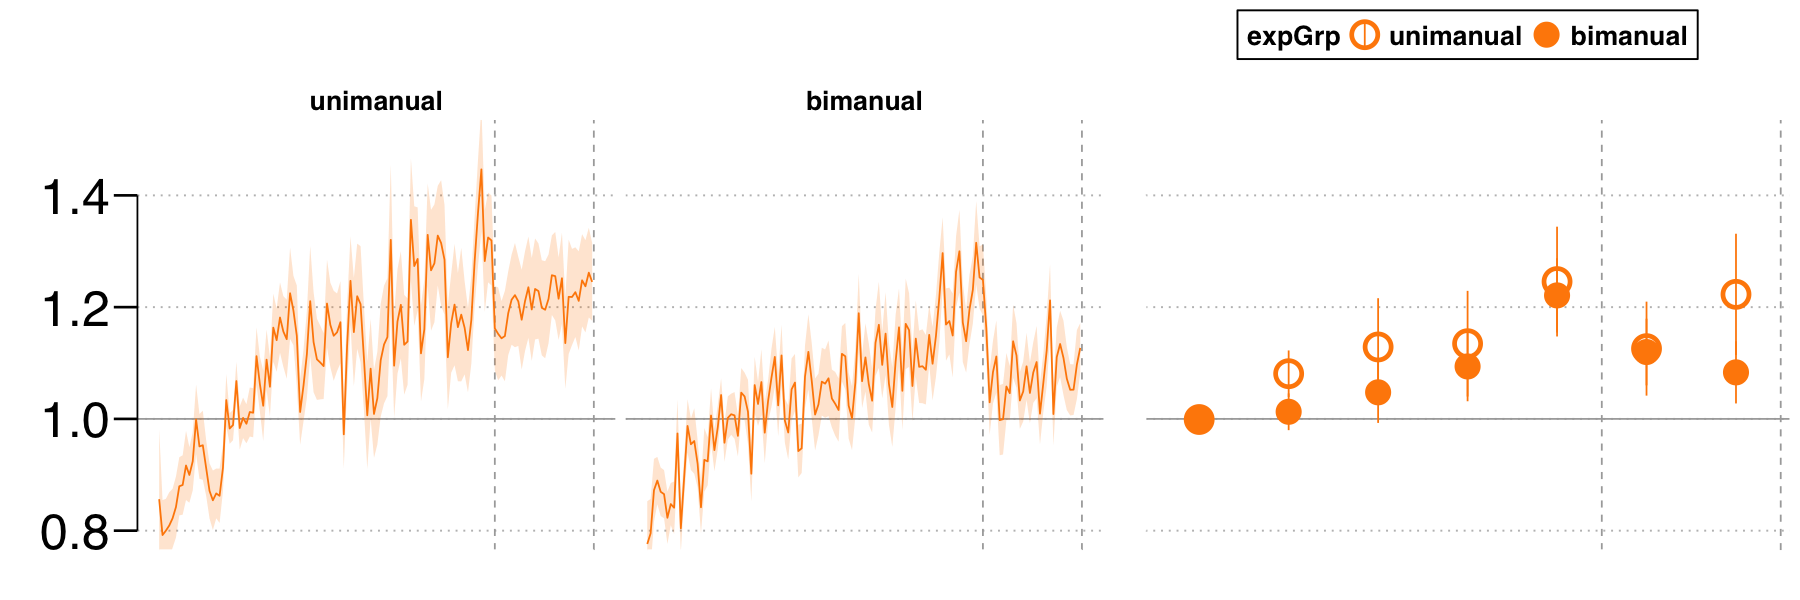

In [14]:
bb = 2
#--------------------------------------------------------------------------

Fig3AnB = ggplot(aes(x = trial,y = slopesR2_corr),
             data = dat3 %>% filter(grp=="adults" & tgtHtC=="narrow")) +
coord_capped_cart(ylim = c(0.8,1.5), xlim = c(1, 260), bottom = 'both', left = 'both') +
geom_vline(xintercept = c(201,260), lty="dashed",col="darkgray") +
geom_hline(yintercept = 1, lty="solid",col="darkgray") +

stat_summary_bin(geom="line",fun.y = mean, col = "#FF8A04",
                 binwidth=bb,lwd=1.25,alpha=1,show.legend = FALSE) +
stat_summary_bin(geom="ribbon",fun.data = mean_se, fill = "#FF8A04",
                 binwidth=bb,lwd=0,alpha=0.2,show.legend = FALSE) +
facet_wrap(~expGrp) + 
xlab("") + ylab("") +

scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) + 
theme_clean() + thm + theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
      # strip.text.x = element_blank(),
      # strip.background = element_blank(),
      axis.text.y = element_text(size = 30),
      axis.ticks.length.y=unit(0.5,units = "cm"),
      axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "black")
     ) 

#--------------------------------------------------------------------------

Fig3C = ggplot(aes(x = cond3,y = slopesR2_corr_mn,
                                shape = expGrp,group=expGrp),
             data = summDat2 %>% filter(grp=="adults" & tgtHtC=="narrow")) +
coord_capped_cart(ylim = c(0.8,1.5),bottom = 'both', left = 'both') +
geom_vline(xintercept = c(5.5,7.5), lty="dashed",col="darkgray") +
geom_hline(yintercept = 1, lty="solid",col="darkgray") +

stat_summary_bin(geom="pointrange",fun.data = mean_se, col = "#FF8A04",
                 lwd=1.25,size = 1.5, stroke = 2, show.legend = TRUE) +
scale_shape_manual(values = c("unimanual" = 1,"bimanual" = 16)) + 
xlab("") + ylab("") +

theme_clean() + thm + theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "white"),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank() 
     ) 

#--------------------------------------------------------------------------
#--------------------------------------------------------------------------

options(repr.plot.width=15, repr.plot.height=5)

Fig3 = Fig3AnB + Fig3C +  plot_layout(widths = c(9,6))
Fig3
# ggsave(file="Fig3_final_v3.svg", bg = "transparent", plot=Fig3, width=15, height=5)


## Figure 4

### Left Panels (A, C, E)
* trial-wise and bin-wise plots 

In [15]:
options(repr.plot.width=5, repr.plot.height=5)
bb = 1 # binwidth for R/L ratio scaling

#--------------------------------------------------------------------------

Fig4A = ggplot(aes(x = trial,y = EarlySlopeAdj_corr,col=tgtHtC,fill=tgtHtC,group=tgtHtC),
             data = dat3 %>% filter(grp=="adults" & expGrp=="bimanual")) +
geom_vline(xintercept = c(201,260), lty="dashed",col="darkgray") +
geom_hline(yintercept = 1, lty="solid",col="darkgray") +
coord_capped_cart(ylim = c(0.8,1.5), xlim = c(1, 260), bottom = 'both', left = 'both') +
stat_summary_bin(geom="line",fun.y = mean,
                 binwidth=bb,lwd=1,alpha=1,show.legend = TRUE) +
stat_summary_bin(geom="ribbon",fun.data = mean_se,
                 binwidth=bb,lwd=0,alpha=0.2,show.legend = FALSE) +

xlab("") + ylab("") +
scale_color_manual(values = c("#D35D27","#1BC7B1")) +
scale_fill_manual(values = c("#D35D27","#1BC7B1")) +

scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) + 
theme_clean() + thm + theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "black")
     ) 

#--------------------------------------------------------------------------

bb = 2 # binwidth for individual hand scaling
Fig4C = ggplot(aes(x = trial,y = slopesR2_corr,col=tgtHtC,fill=tgtHtC,group=tgtHtC),
             data = dat3 %>% filter(grp=="adults" & expGrp=="bimanual")) +
coord_capped_cart(ylim = c(0.8,1.5), xlim = c(1, 260), bottom = 'both', left = 'both') +
geom_vline(xintercept = c(201,260), lty="dashed",col="darkgray") +
geom_hline(yintercept = 1, lty="solid",col="darkgray") +

stat_summary_bin(geom="line",fun.y = mean,
                 binwidth=bb,lwd=1,alpha=1,show.legend = FALSE) +
stat_summary_bin(geom="ribbon",fun.data = mean_se,
                 binwidth=bb,lwd=0,alpha=0.2,show.legend = FALSE) +
xlab("") + ylab("") +
scale_color_manual(values = c("#FF8A04","#6CE1D1")) +
scale_fill_manual(values = c("#FF8A04","#6CE1D1")) +
scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) + 
theme_clean() + thm + theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     # axis.line.y = element_line(colour = "white"),
     #  axis.text.y = element_blank(),
     #  axis.ticks.y = element_blank() 
     ) 

#--------------------------------------------------------------------------

Fig4E = ggplot(aes(x = trial,y = slopesL2_corr,col=tgtHtC,fill=tgtHtC,group=tgtHtC),
             data = dat3 %>% filter(grp=="adults" & expGrp=="bimanual")) +
coord_capped_cart(ylim = c(0.8,1.5), xlim = c(1, 260), bottom = 'both', left = 'both') +
geom_vline(xintercept = c(201,260), lty="dashed",col="darkgray") +
geom_hline(yintercept = 1, lty="solid",col="darkgray") +

stat_summary_bin(geom="line",fun.y = mean,
                 binwidth=bb,lwd=1,alpha=1,show.legend = TRUE) +
stat_summary_bin(geom="ribbon",fun.data = mean_se,
                 binwidth=bb,lwd=0,alpha=0.2,show.legend = FALSE) +

xlab("") + ylab("") +
scale_color_manual(values = c("black","darkgray")) +
scale_fill_manual(values = c("black","darkgray")) +

scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) + 
theme_clean() + thm + theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     # axis.line.y = element_line(colour = "white"),
     #  axis.text.y = element_blank(),
     #  axis.ticks.y = element_blank() 
     ) 


### Right Panels (B, D, F)
* summary averages 

In [16]:
Fig4B = ggplot(aes(x = cond3,y = EarlySlopeAdj_corr_mn,col=tgtHtC,fill=tgtHtC,
                          group=tgtHtC),
             data = summDat2 %>% filter(grp=="adults" & expGrp=="bimanual")) +
coord_capped_cart(ylim = c(0.8,1.5), bottom = 'both', left = 'both') +
geom_vline(xintercept = c(5.5,7.5), lty="dashed",col="darkgray") +
geom_hline(yintercept = 1, lty="solid",col="darkgray") +

stat_summary_bin(geom="pointrange",fun.data = mean_se,
                lwd=1.25,alpha=1,size = 1, show.legend = FALSE) +

xlab("") + ylab("") +
scale_color_manual(values = c("#D35D27","#1BC7B1")) +
scale_fill_manual(values = c("#D35D27","#1BC7B1")) +
theme_clean() + thm + theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "white"),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank() 
     ) 

#--------------------------------------------------------------------------

Fig4D = ggplot(aes(x = cond3,y = slopesR2_corr_mn,col=tgtHtC,fill=tgtHtC,
                          group=tgtHtC),
             data = summDat2 %>% filter(grp=="adults" & expGrp=="bimanual")) +
coord_capped_cart(ylim = c(0.8,1.5),bottom = 'both', left = 'both') +
geom_vline(xintercept = c(5.5,7.5), lty="dashed",col="darkgray") +
geom_hline(yintercept = 1, lty="solid",col="darkgray") +

stat_summary_bin(geom="pointrange",fun.data = mean_se,
                 lwd=1.25,alpha=1,size = 1,show.legend = FALSE) +

xlab("") + ylab("") +
scale_color_manual(values = c("#FF8A04","#6CE1D1")) +
scale_fill_manual(values = c("#FF8A04","#6CE1D1")) +
theme_clean() + thm + theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "white"),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank() 
     ) 

#--------------------------------------------------------------------------

Fig4F = ggplot(aes(x = cond3,y = slopesL2_corr_mn,col=tgtHtC,fill=tgtHtC,group=tgtHtC),
             data = summDat2 %>% filter(grp=="adults" & expGrp=="bimanual")) +
coord_capped_cart(ylim = c(0.8,1.5), bottom = 'both', left = 'both') +
geom_vline(xintercept = c(5.5,7.5), lty="dashed",col="darkgray") +
geom_hline(yintercept = 1, lty="solid",col="darkgray") +

stat_summary_bin(geom="pointrange",fun.data = mean_se,
                lwd=1.25,alpha=1,size = 1,show.legend = FALSE) +

xlab("") + ylab("") +
scale_color_manual(values = c("black","darkgray")) +
scale_fill_manual(values = c("black","darkgray")) +
theme_clean() + thm + theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "white"),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank() 
     ) 


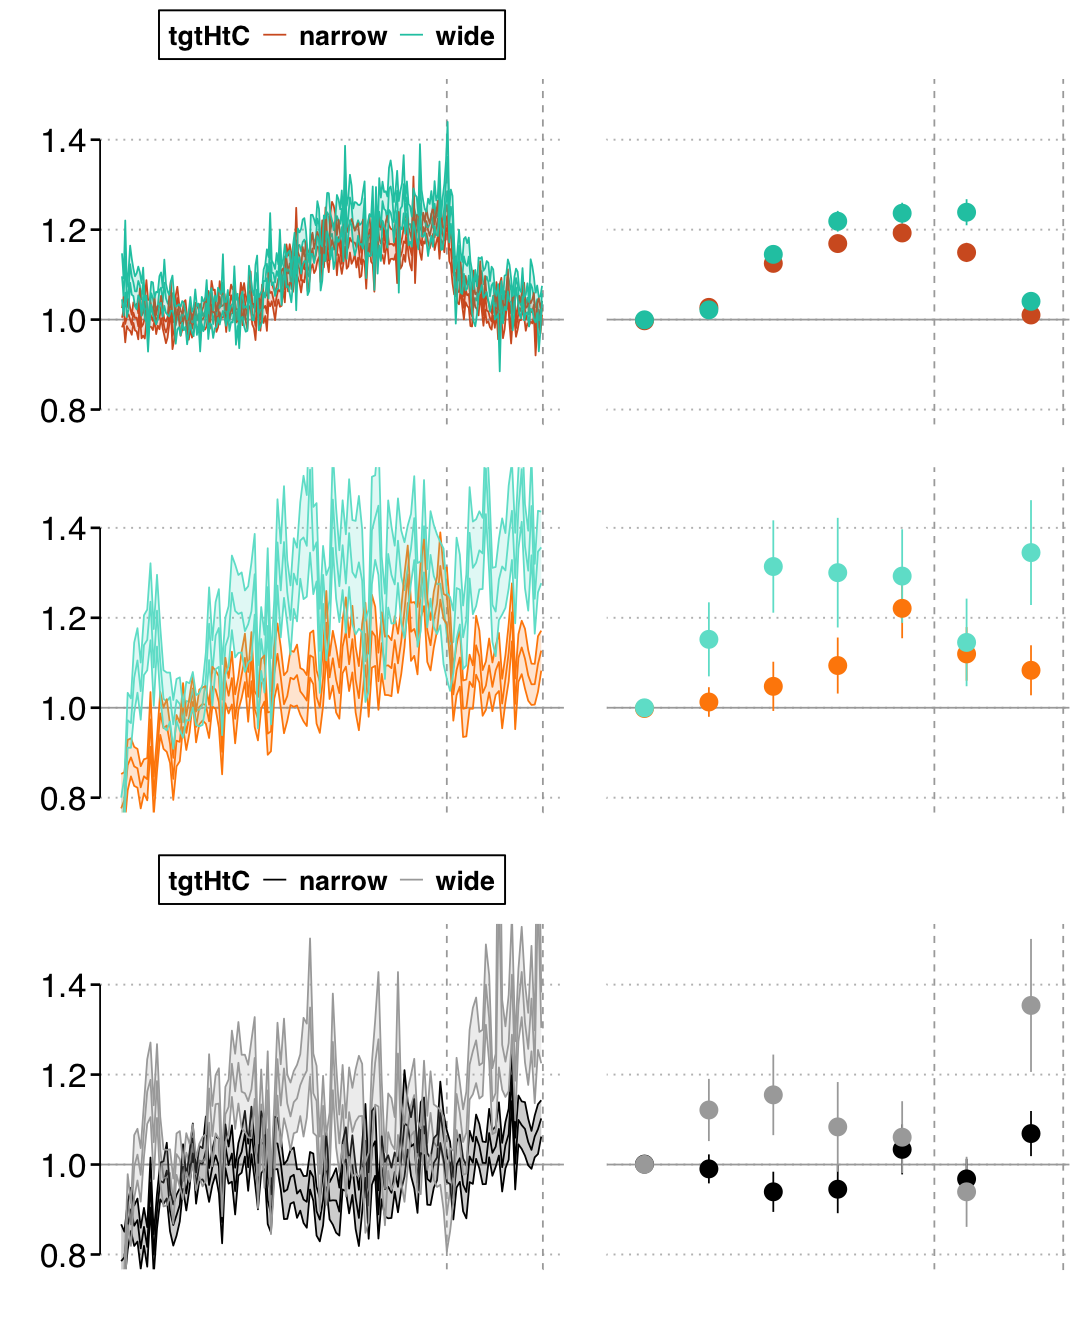

In [17]:
options(repr.plot.width = 9, repr.plot.height = 11)

Fig4 <- (Fig4A + Fig4B) / (Fig4C + Fig4D) / (Fig4E + Fig4F) + 
        plot_layout(heights = c(1,1,1), widths = c(1,1,1)) # Adjust widths if necessary

# Save or display the figure
# ggsave(file="Fig4_final.svg", plot=Fig4, width=9, height=11)
Fig4


## Figure 5

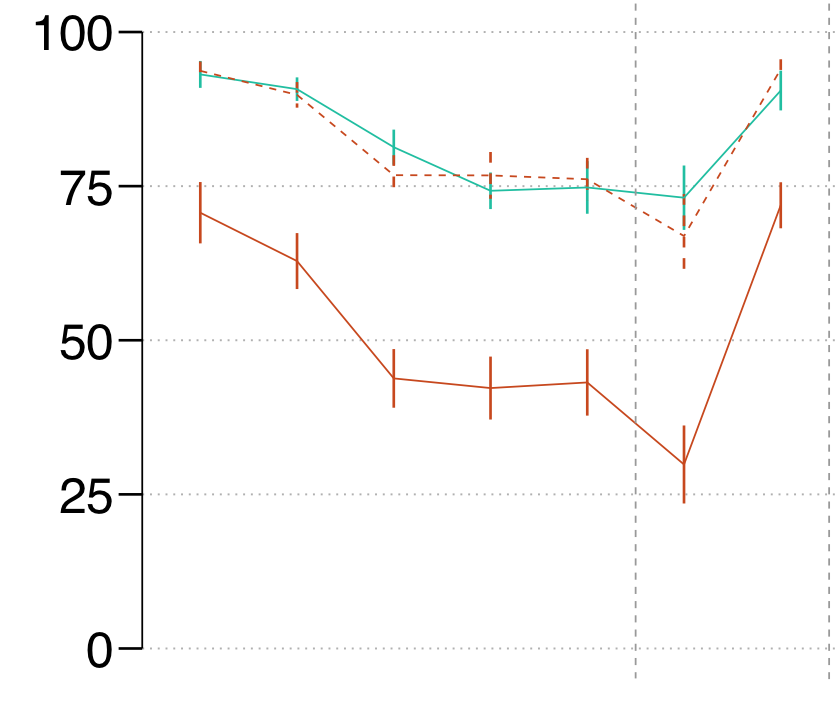

In [18]:
options(repr.plot.width=7, repr.plot.height=6)

#--------------------------------------------------------------------------

Fig5 = ggplot(data = summDat2 %>% filter(grp=="adults"), 
        aes(x =cond3,y= succRate_mn,group=OmniGrp, col = tgtHtC, lty = expGrp)) + 

coord_capped_cart(ylim = c(0,100),left = 'both',bottom = 'both') +  #for signed values

stat_summary(geom="errorbar", size = 0.75, width=0,l6 = 2.5, stroke = 2.5, 
             fun.data=mean_se, show.legend = FALSE) + 
stat_summary(geom="line", fun.y=mean,alpha = 1, l6 = 2.5, show.legend=FALSE) + 
scale_color_manual(values = c("#D35D27","#1BC7B1")) +
scale_linetype_manual(values = c("bimanual" = "solid","unimanual" = "dashed")) +

geom_vline(xintercept = c(5.5,7.5), lty="dashed",col="darkgray") +
xlab("") + ylab("") +
theme_clean() + thm + theme(plot.margin = unit(c(0.01, 0.01, 0.01, 0.01),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
      axis.text.y = element_text(size = 30),
      axis.ticks.length.y=unit(0.5,units = "cm"),
      axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "black")
     )

#--------------------------------------------------------------------------
Fig5
# ggsave(file="Fig5_final.svg", bg = "transparent", plot=combSucc, width=7, height=6)


## Figure 6

**Specify example subject to plot**<br>
and conversion factor for gainF to be in 'displacement' values

In [19]:
bex = "MUH249" # specify bimanual-narrow example to plot
fct = 0.3      # this is to plot "target zone" using gainF (inverse of gain)

### Top Panels (D, E, F)
* seen elements displacement (plate, seen right, seen left)

In [20]:
options(repr.plot.width=12, repr.plot.height=3)

#--------------------------------------------------------------------------

Fig6D = ggplot(aes(x = trial,y = Py_raw , label = trial, group=cond, shape=as.factor(reward)),
             data = dat3 %>% filter(grp=="adults" & subj==bex)) +
geom_line(aes(y = fct),col="black",size =1.5) +
geom_ribbon(aes(ymin = ((0.3-(fct*0.05*as.double(tgtHt)/3))),
                ymax = ((0.3+(fct*0.05*as.double(tgtHt)/3)))),
            col=NA,fill = "gray", alpha = .5) +
geom_point(col="darkgreen", size=1.5, stroke=1.5, show.legend = FALSE) +
coord_capped_cart(ylim = c(0.15,0.45), xlim = c(1, 260), bottom = 'both',left="both") +
scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
theme_clean() + thm +
scale_shape_manual(values = c(1,16)) +
xlab("") + ylab("") +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      # axis.text.y = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.4,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     # axis.ticks.y = element_blank(),
     axis.line.y = element_line(colour = "black")
     )

#--------------------------------------------------------------------------

Fig6E = ggplot(aes(x = trial,y = sRy_raw, group=cond, shape=as.factor(reward)),
             data = dat3 %>% filter(grp=="adults" & subj==bex)) +
geom_line(aes(y = fct),col="black",size =1.5) +
geom_ribbon(aes(ymin = ((0.3-(fct*0.05*as.double(tgtHt)/3))),
                ymax = ((0.3+(fct*0.05*as.double(tgtHt)/3)))),
            col=NA,fill = "gray", alpha = .5) +
geom_point(size = 1.5, stroke=1.5, col ="#FFCA00", show.legend = FALSE ) +
scale_shape_manual(values = c(1,16)) +
coord_capped_cart(ylim = c(0.15,0.45), xlim = c(1, 260), bottom = 'both', left = 'both') +
scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
xlab("") + ylab("") + # ggtitle("bimanual-3 example") +
theme_clean() + thm +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      axis.text.y = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.4,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "white"),
     axis.ticks.y = element_blank()
     )
#--------------------------------------------------------------------------

Fig6F = ggplot(aes(x = trial,y = Ly_raw, group=cond, shape=as.factor(reward)),
             data = dat3 %>% filter(grp=="adults" & subj==bex)) +
geom_line(aes(y = fct),col="black",size =1.5) +
geom_ribbon(aes(ymin = ((0.3-(fct*0.05*as.double(tgtHt)/3))),
                ymax = ((0.3+(fct*0.05*as.double(tgtHt)/3)))),
            col=NA,fill = "gray", alpha = .5) +
geom_point(size = 1.5, stroke=1.5, col ="#808080", show.legend = FALSE ) +
scale_shape_manual(values = c(1,16)) +
coord_capped_cart(ylim = c(0.15,0.45), xlim = c(1, 260), bottom = 'both', left = 'both') +
scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
xlab("") + ylab("") + # ggtitle("bimanual-3 example") +
theme_clean() + thm +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      axis.text.y = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.4,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "white"),
     axis.ticks.y = element_blank()
     )

# Fig6D | Fig6E | Fig6F

### Bottom Panels (G, H, I)
* 'real' and computed elements (tilt compensations, real right hand, total displacement)

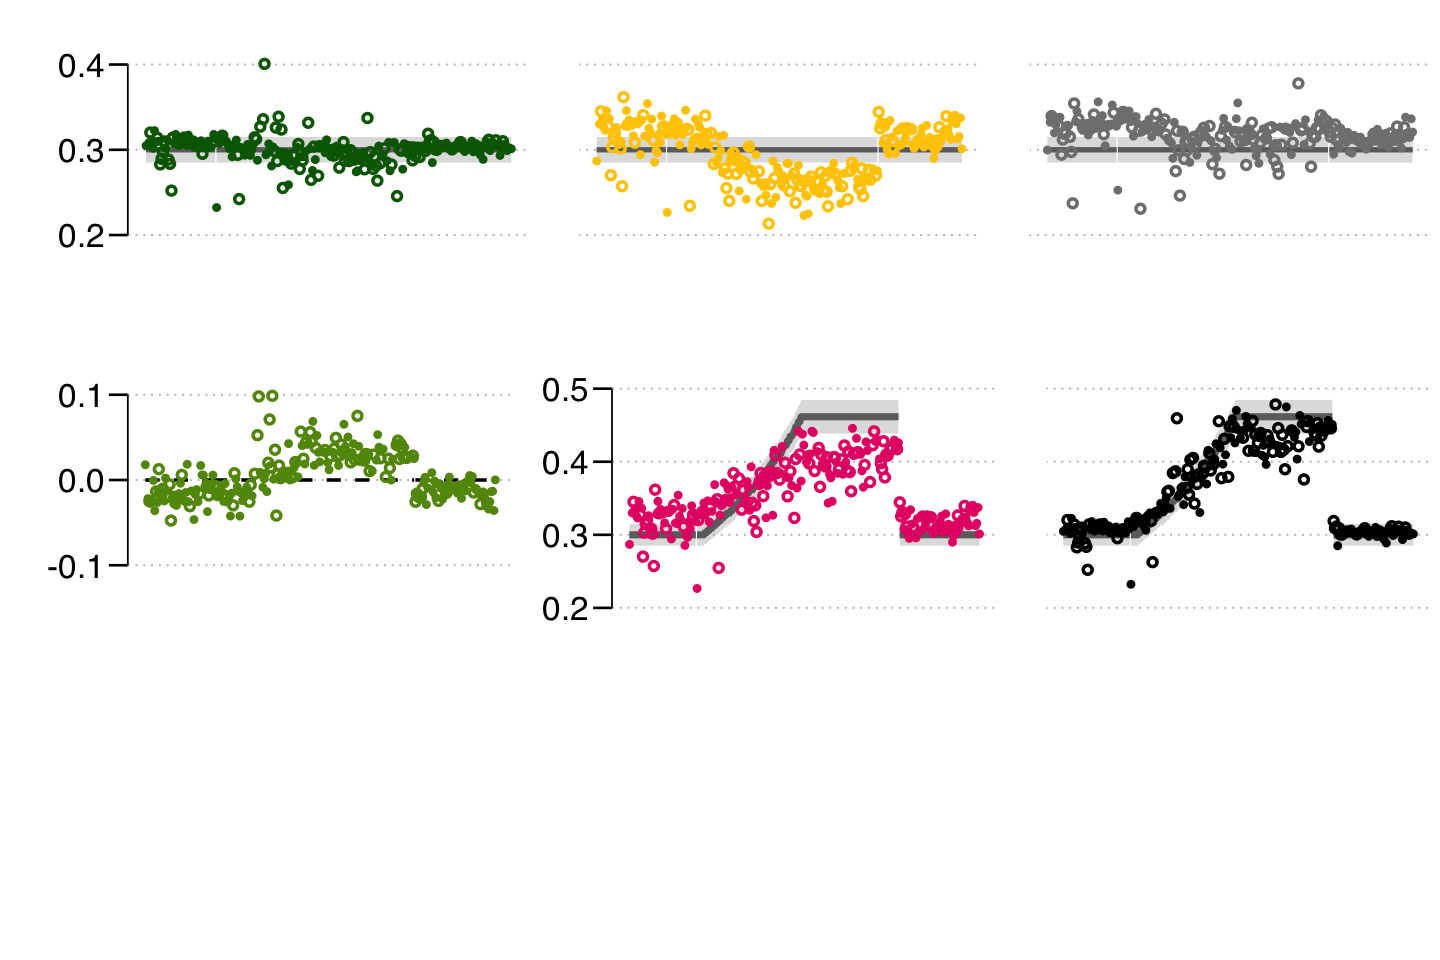

In [21]:
options(repr.plot.width=12, repr.plot.height=4)

#--------------------------------------------------------------------------

Fig6G = ggplot(aes(x = trial,y =(Py_raw - sRy_raw), group=cond, shape=as.factor(reward)),
             data = dat3 %>% filter(grp=="adults" & subj==bex)) +
coord_capped_cart(ylim = c(-0.15,0.15), xlim = c(1, 260), bottom = 'both', left = 'both') +
geom_line(aes(y = 0),col="black",size =1, lty="dashed") +
geom_point(col="#639507", size=1.5, stroke=1.5, show.legend = FALSE) +
scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
theme_clean() + thm +
scale_shape_manual(values = c(1,16)) +
xlab("") + ylab("") +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      # axis.text.y = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.4,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     # axis.line.y = element_line(colour = "white"),
     # axis.ticks.y = element_blank()
     )

#--------------------------------------------------------------------------

Fig6H = ggplot(aes(x = trial,y = Ry_raw, group=cond, shape=as.factor(reward)),
             data = dat3 %>% filter(grp=="adults" & subj==bex)) +
geom_line(aes(y = fct*gainF),col="black",size =2) +
geom_ribbon(aes(ymin = (fct*(gainF-(gainF*0.05*as.double(tgtHt)/3))),
                ymax = (fct*(gainF+(gainF*0.05*as.double(tgtHt)/3)))),
            col=NA,fill = "gray", alpha = .5) +
geom_point(size = 1.5, stroke=1.5, col ="#E51574", show.legend = FALSE ) +

scale_shape_manual(values = c("0" = 1,"1" = 16)) + #0 -> failure; 1-> reward
coord_capped_cart(ylim = c(0.2,0.55), xlim = c(1, 260), bottom = 'both', left = 'both') +
scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
xlab("") + ylab("") + # ggtitle("bimanual-3 example") +
theme_clean() + thm +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      # axis.text.y = element_blank(),
      panel.border = element_blank(),
     axis.ticks.length=unit(0.4,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "black"),
     # axis.ticks.y = element_blank()
     )  

#--------------------------------------------------------------------------

Fig6I = ggplot(aes(x = trial,y = totDispR_raw, group=cond, shape=as.factor(reward)),
             data = dat3 %>% filter(grp=="adults" & subj==bex)) +
geom_line(aes(y = fct*gainF),col="black",size =2) +
geom_ribbon(aes(ymin = (fct*(gainF-(gainF*0.05*as.double(tgtHt)/3))),
                ymax = (fct*(gainF+(gainF*0.05*as.double(tgtHt)/3)))),
            col=NA,fill = "gray", alpha = .5) +
geom_point(size = 1.5, stroke=1.5, col ="black", show.legend = FALSE ) +
scale_shape_manual(values = c(1,16)) +
coord_capped_cart(ylim = c(0.2,0.55), xlim = c(1, 260), bottom = 'both', left = 'both') +
scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
xlab("") + ylab("") + # ggtitle("bimanual-3 example") +
theme_clean() + thm +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
     axis.ticks.length=unit(0.4,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "white"),
     axis.text.y = element_blank(),
     panel.border = element_blank(),
     axis.ticks.y = element_blank()
     )

# Fig6G | Fig6H | Fig6I

#--------------------------------------------------------------------------
#--------------------------------------------------------------------------

options(repr.plot.width=12, repr.plot.height=8)

# Combine your panels into the two rows
top_panels = (Fig6D + Fig6E + Fig6F)
bottom_panels = (Fig6G + Fig6H + Fig6I)

# Apply the layout with specified heights for the second row (bottom)
indiv_example = top_panels / bottom_panels + plot_layout(heights = c(3, 5)) + plot_layout(heights = c(1, 1, 1)) 

indiv_example
# ggsave(file="Fig.svg", bg = "transparent", plot=indiv_example, width=12, height=10)


## Figure 7

In [38]:
# for the group data
fct = 1
al = 0.8
bb = 1

### Left Panels (A, C, F)

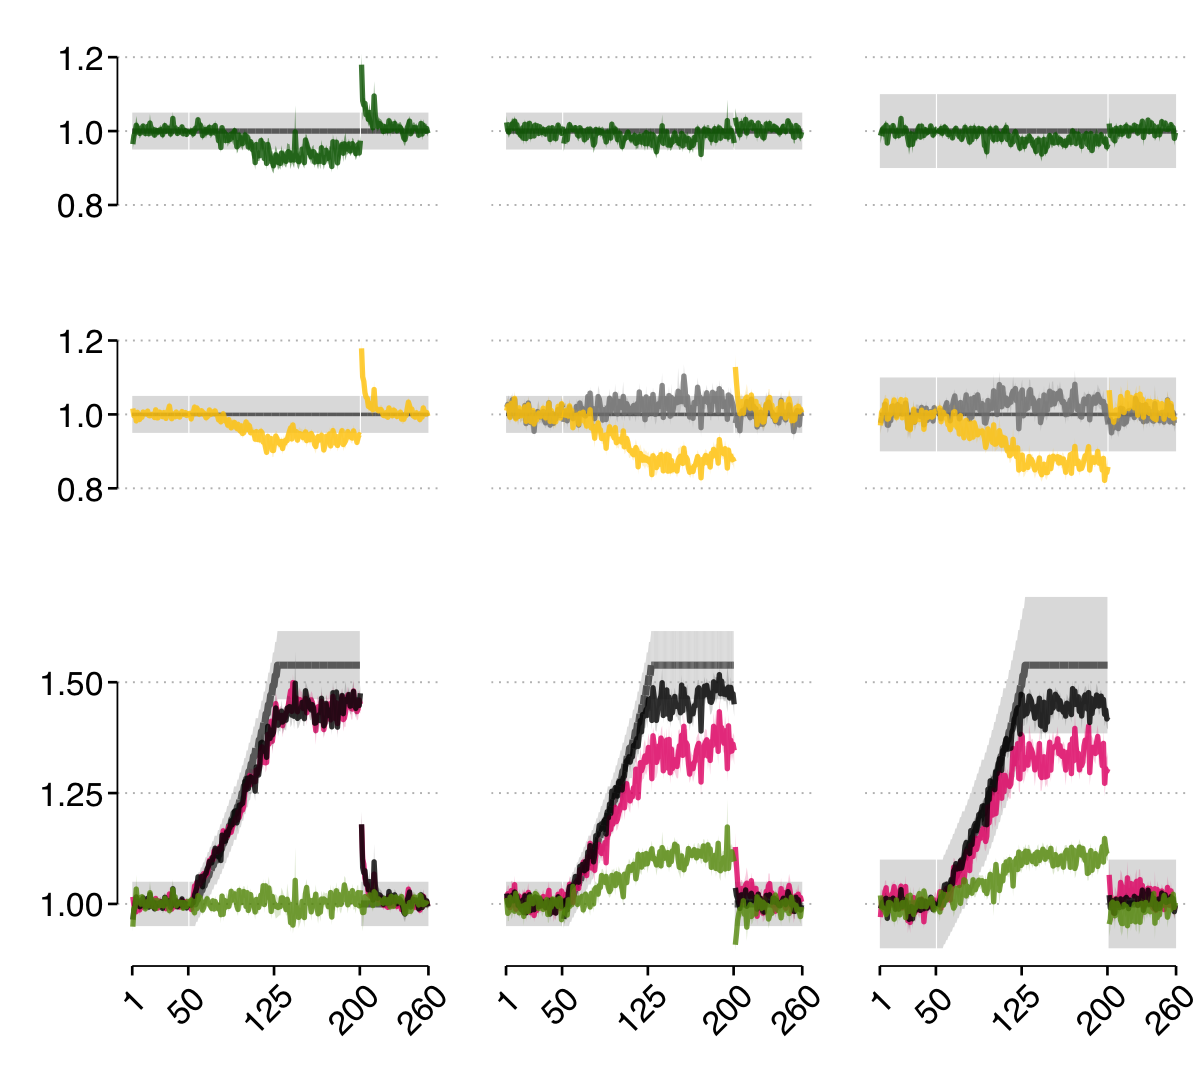

In [41]:
Fig7A = ggplot(aes(x = trial,y = (Py_corr), group=cond),
             data = dat3 %>% filter(grp=="adults" & subj!="MUH294")) +
geom_line(aes(y = fct),col="black",size =1.5) +
geom_ribbon(aes(ymin = ((fct-(fct*0.05*as.double(tgtHt)/3))),
                ymax = ((fct+(fct*0.05*as.double(tgtHt)/3)))),
            col=NA,fill = "gray", alpha = .5) +
coord_capped_cart(ylim = c(0.7,1.3), xlim = c(1, 260), bottom = 'both', left = 'both') +

stat_summary_bin(geom="ribbon", fill="darkgreen",
                 fun.data = mean_se,
                 binwidth=bb,lwd=NA,alpha=0.5,show.legend = FALSE) +
stat_summary_bin(geom="line",fun.y = mean,col="darkgreen",
                 binwidth=bb,lwd=1.5,alpha=al,show.legend = TRUE) +
scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
ylab("") +xlab("") +
facet_wrap(~tgtHtC*expGrp,ncol = 4) +
theme_clean() + thm +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
      panel.spacing = unit(2, "lines"),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "black"),
     strip.text.x = element_blank()
     )

#--------------------------------------------------------------------------

Fig7C = ggplot(aes(x = trial,y = Ly_corr, group=cond),
             data = dat3 %>% filter(grp=="adults")) +
coord_capped_cart(ylim = c(0.7,1.3), xlim = c(1, 260), bottom = 'both', left = 'both') +
 
geom_line(aes(y = 1),col="black",size =1) +
geom_ribbon(aes(ymin = ((1-(fct*0.05*as.double(tgtHt)/3))),
                ymax = ((1+(fct*0.05*as.double(tgtHt)/3)))),
            col=NA,fill = "gray", alpha = .5) +
stat_summary_bin(data = dat3 %>% filter(grp=="adults" & expGrp=="bimanual"),
                 geom="ribbon", fill="#808080",
                 fun.data = mean_se,
                 binwidth=bb,lwd=NA,alpha=0.2,show.legend = FALSE) +
stat_summary_bin(data = dat3 %>% filter(grp=="adults" & expGrp=="bimanual"),
                 geom="line",fun.y = mean,col="#808080",
                 binwidth=bb,lwd=1.5,alpha=al,show.legend = TRUE) +

stat_summary_bin(data = dat3 %>% filter(grp=="adults"),
                 aes(y = sRy_corr), geom="ribbon", fill="#FFCA00",
                 fun.data = mean_se,
                 binwidth=bb,lwd=NA,alpha=0.2,show.legend = FALSE) +
stat_summary_bin(data = dat3 %>% filter(grp=="adults"),
                 aes(y = sRy_corr), geom="line",fun.y = mean,col="#FFCA00",
                 binwidth=bb,lwd=1.5,alpha=al,show.legend = TRUE) +

scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
ylab("") +xlab("") +
facet_wrap(~tgtHtC*expGrp,ncol = 4) +
theme_clean() + thm +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(plot.background = element_blank(),
       axis.text.x = element_blank(),
      panel.border = element_blank(),
      panel.spacing = unit(2, "lines"),
     axis.ticks.length=unit(0.2,"cm"),
      axis.ticks.x = element_blank(),
      legend.position="top",
     axis.line.x = element_line(colour = "white"),
     axis.line.y = element_line(colour = "black"),
     strip.text.x = element_blank()
     )

#--------------------------------------------------------------------------

Fig7F = ggplot(aes(x = trial,y = Ry_corr, group=cond),
             data = dat3 %>% filter(grp=="adults")) +
coord_capped_cart(ylim = c(0.9,1.7), xlim = c(1, 260), bottom = 'both', left = 'both') +
 
geom_line(aes(y = fct*gainF),col="black",size =2) +
geom_ribbon(aes(ymin = (fct*(gainF-(gainF*0.05*as.double(tgtHt)/3))),
                ymax = (fct*(gainF+(gainF*0.05*as.double(tgtHt)/3)))),
            col=NA,fill = "gray", alpha = .5) +
stat_summary_bin(geom="ribbon", fill="#E51574",
                 fun.data = mean_se,
                 binwidth=bb,lwd=NA,alpha=0.2,show.legend = FALSE) +
stat_summary_bin(geom="line",fun.y = mean,col="#E51574",
                 binwidth=bb,lwd=1.5,alpha=al,show.legend = TRUE) +
stat_summary_bin(aes(y = totDispR_corr), geom="ribbon",
                 fun.data = mean_se, col = "gray",
                 binwidth=bb,lwd=NA,alpha=0.2,show.legend = FALSE) +
stat_summary_bin(aes(y = totDispR_corr),geom="line",fun.y = mean, col="black",
                 binwidth=bb,lwd=1.5,alpha=al,show.legend = TRUE) +
stat_summary_bin(aes(y = 1+ tilt_comp), geom="ribbon", fill="#639507",
                 fun.data = mean_se,
                 binwidth=bb,lwd=NA,alpha=0.2,show.legend = FALSE) +
stat_summary_bin(aes(y = 1+ tilt_comp), geom="line",fun.y = mean,col="#639507",
                 binwidth=bb,lwd=1.5,alpha=al,show.legend = TRUE) +

scale_x_continuous(breaks = c(1,50,125,200,260), labels = c("1","50","125","200", "260")) +
ylab("") +xlab("") +
facet_wrap(~tgtHtC*expGrp,ncol = 4) +
theme_clean() + thm +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(plot.background = element_blank(),
      panel.border = element_blank(),
      panel.spacing = unit(2, "lines"),
     axis.ticks.length=unit(0.2,"cm"),
      legend.position="top",
     axis.line.y = element_line(colour = "black"),
      axis.text.x = element_text(angle = 45, vjust = 0.8, hjust=0.8),
     strip.background = element_blank(),
     strip.text.x = element_blank()
     )

#--------------------------------------------------------------------------
#--------------------------------------------------------------------------

options(repr.plot.width=10, repr.plot.height=9)

Fig7_leftpanels = (Fig7A/Fig7C/Fig7F) + plot_layout(heights = c(2.5,2.5,4))
# Fig7_leftpanels


### Right Panels (B, D, E, J, H, I)

**Prep steps**<br>
define experimental phases to plot, relevel 3 groups, remove left hand from UNI

In [24]:
# to select only end plateay and start washout define a var cc
cc = c("end.plateau","start.washout")

# to relevel OmniGrp for plotting so uni-narrow is leftmost, then bi-narrow, then bi-wide
summDat2$OmniGrp = factor(summDat2$OmniGrp,levels = c("uni-narrow","bi-narrow","bi-wide"))

# we don't want to plot left hand for unimanual
summDat2$Ly_corr_mn[summDat2$OmniGrp=="uni-narrow"] = NA

In [42]:
Fig7B = ggplot(data = summDat2 %>% filter(grp=="adults" & cond3%in%cc),
        aes(x =OmniGrp,y=Py_corr_mn,label=subj)) +
stat_summary(geom="pointrange", size = 0.9, l6 = 1.25, width = 0.3, fun.data=mean_ci, col="darkgreen",
                position = position_nudge(x = 0)) +
xlab("") + ylab("") +
geom_hline(yintercept = 1,col = "black",lty = "dashed") + 
coord_capped_cart(ylim = c(0.7,1.3), bottom = 'both', left = 'both') +
facet_wrap(~cond3,ncol = 3) +
theme_pubclean() + thm +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(axis.text.x = element_blank(),
      axis.ticks.x = element_blank(),
      strip.background = element_blank(),
      strip.text.x = element_blank(),
      panel.border = element_blank(),
            panel.spacing = unit(1, "lines"),
      axis.line.x = element_line(colour = NA))

#--------------------------------------------------------------------------

Fig7D = ggplot(data = summDat2 %>% filter(grp=="adults" & cond3%in%cc),
        aes(x =OmniGrp,y=sRy_corr_mn,label=subj)) +
geom_hline(yintercept = 1,col = "black",lty = "dashed") + 
stat_summary(geom="pointrange",  size = 0.9, l6 = 1.25, fun.data=mean_ci, col="#FFCA00",
                position = position_nudge(x = 0)) +
xlab("") + ylab("") +
coord_capped_cart(ylim = c(0.7,1.3), bottom = 'both', left = 'both') +
facet_wrap(~cond3,ncol = 3) +
theme_pubclean() + thm +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(axis.text.x = element_blank(),
      axis.ticks.x = element_blank(),
      strip.background = element_blank(),
      strip.text.x = element_blank(),
      panel.border = element_blank(),
            panel.spacing = unit(1, "lines"),
      axis.line.x = element_line(colour = NA))

#--------------------------------------------------------------------------

Fig7E = ggplot(data = summDat2 %>% filter(grp=="adults" & cond3%in%cc),
        aes(x =OmniGrp,y=Ly_corr_mn,label=subj)) +
geom_hline(yintercept = 1,col = "black",lty = "dashed") + 
stat_summary(geom="pointrange",  size = 0.9, l6 = 1.25, fun.data=mean_ci, col="#808080",
                position = position_nudge(x = 0)) +
xlab("") + ylab("") +
coord_capped_cart(ylim = c(0.7,1.3), bottom = 'both', left = 'both') +
facet_wrap(~cond3,ncol = 3) +
theme_pubclean() + thm +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(axis.text.x = element_blank(),
      axis.ticks.x = element_blank(),
      strip.background = element_blank(),
      strip.text.x = element_blank(),
      panel.border = element_blank(),
                  panel.spacing = unit(1, "lines"),
      axis.line.x = element_line(colour = NA),
     axis.line.y = element_line(colour = "white"),
     axis.text.y = element_blank(),
     axis.ticks.y = element_blank())

#--------------------------------------------------------------------------

Fig7G = ggplot(data = summDat2 %>% filter(grp=="adults" & cond3%in%cc),
        aes(x =OmniGrp,y=totDispR_corr_mn,label=subj)) +
geom_hline(yintercept = 1,col = "black",lty = "dashed") + 
stat_summary(geom="pointrange",  size = 0.9, l6 = 1.25, fun.data=mean_ci, col="black",
                position = position_nudge(x = 0)) +
xlab("") + ylab("") +
coord_capped_cart(ylim = c(0.9, 1.7), bottom = 'both', left = 'both') +
facet_wrap(~cond3,ncol = 3) +
theme_pubclean() + thm +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(strip.background = element_blank(),
      strip.text.x = element_blank(),
      panel.border = element_blank(),
                  panel.spacing = unit(1, "lines")) +
theme(axis.text.x = element_text(angle = 45, vjust = 0.9, hjust=0.8))

#--------------------------------------------------------------------------

Fig7H = ggplot(data = summDat2 %>% filter(grp=="adults" & cond3%in%cc),
        aes(x = OmniGrp, y = Ry_corr_mn, label = subj)) +
geom_hline(yintercept = 1,col = "black",lty = "dashed") + 
stat_summary(geom = "pointrange",  size = 0.9, l6 = 1.25, fun.data = mean_ci, col = "#E0367C",
                position = position_nudge(x = 0)) + 
  xlab("") + ylab("") +
  coord_capped_cart(ylim = c(0.9, 1.7), bottom = 'both', left = 'both') +
  facet_wrap(~cond3, ncol = 3) +
  theme_pubclean() + thm +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(strip.background = element_blank(),
      strip.text.x = element_blank(),
      panel.border = element_blank(),
                  panel.spacing = unit(1, "lines"),
          axis.line.y = element_line(colour = "white"),
     axis.text.y = element_blank(),
     axis.ticks.y = element_blank()) +
theme(axis.text.x = element_text(angle = 45, vjust = 0.9, hjust=0.8))

#--------------------------------------------------------------------------

Fig7I = ggplot(data = summDat2 %>% filter(grp=="adults" & cond3%in%cc),
        aes(x =OmniGrp,y=1+tilt_comp_mn,label=subj)) +
geom_hline(yintercept = 1,col = "black",lty = "dashed") + 
stat_summary(geom="pointrange", size = 0.9, l6 = 1.25, fun.data=mean_ci, col="#639507",
                position = position_nudge(x = 0)) +
xlab("") + ylab("") +
coord_capped_cart(ylim = c(0.9, 1.7), bottom = 'both', left = 'both') +
facet_wrap(~cond3,ncol = 3) +
theme_pubclean() + thm +
theme(plot.margin = unit(c(0, 0, 0, 0),"inches")) +
theme(strip.background = element_blank(),
      strip.text.x = element_blank(),
      panel.border = element_blank(), 
                  panel.spacing = unit(1, "lines"),
      axis.line.y = element_line(colour = "white"),
     axis.text.y = element_blank(),
     axis.ticks.y = element_blank()) +
theme(axis.text.x = element_text(angle = 45, vjust = 0.9, hjust=0.8))

#--------------------------------------------------------------------------
#--------------------------------------------------------------------------

options(repr.plot.width=9, repr.plot.height=10)

Fig7_rightpanels = 
(Fig7B + plot_spacer() + plot_spacer() + plot_layout(widths = c(3,3,3))) /
(Fig7D + Fig7E + plot_spacer() + plot_layout(widths = c(3,3,3))) /
(Fig7G + Fig7H + Fig7I + plot_layout(widths = c(3,3,3))) + 
plot_layout(heights = c(3.5,3.5,5))

# Fig7_rightpanels

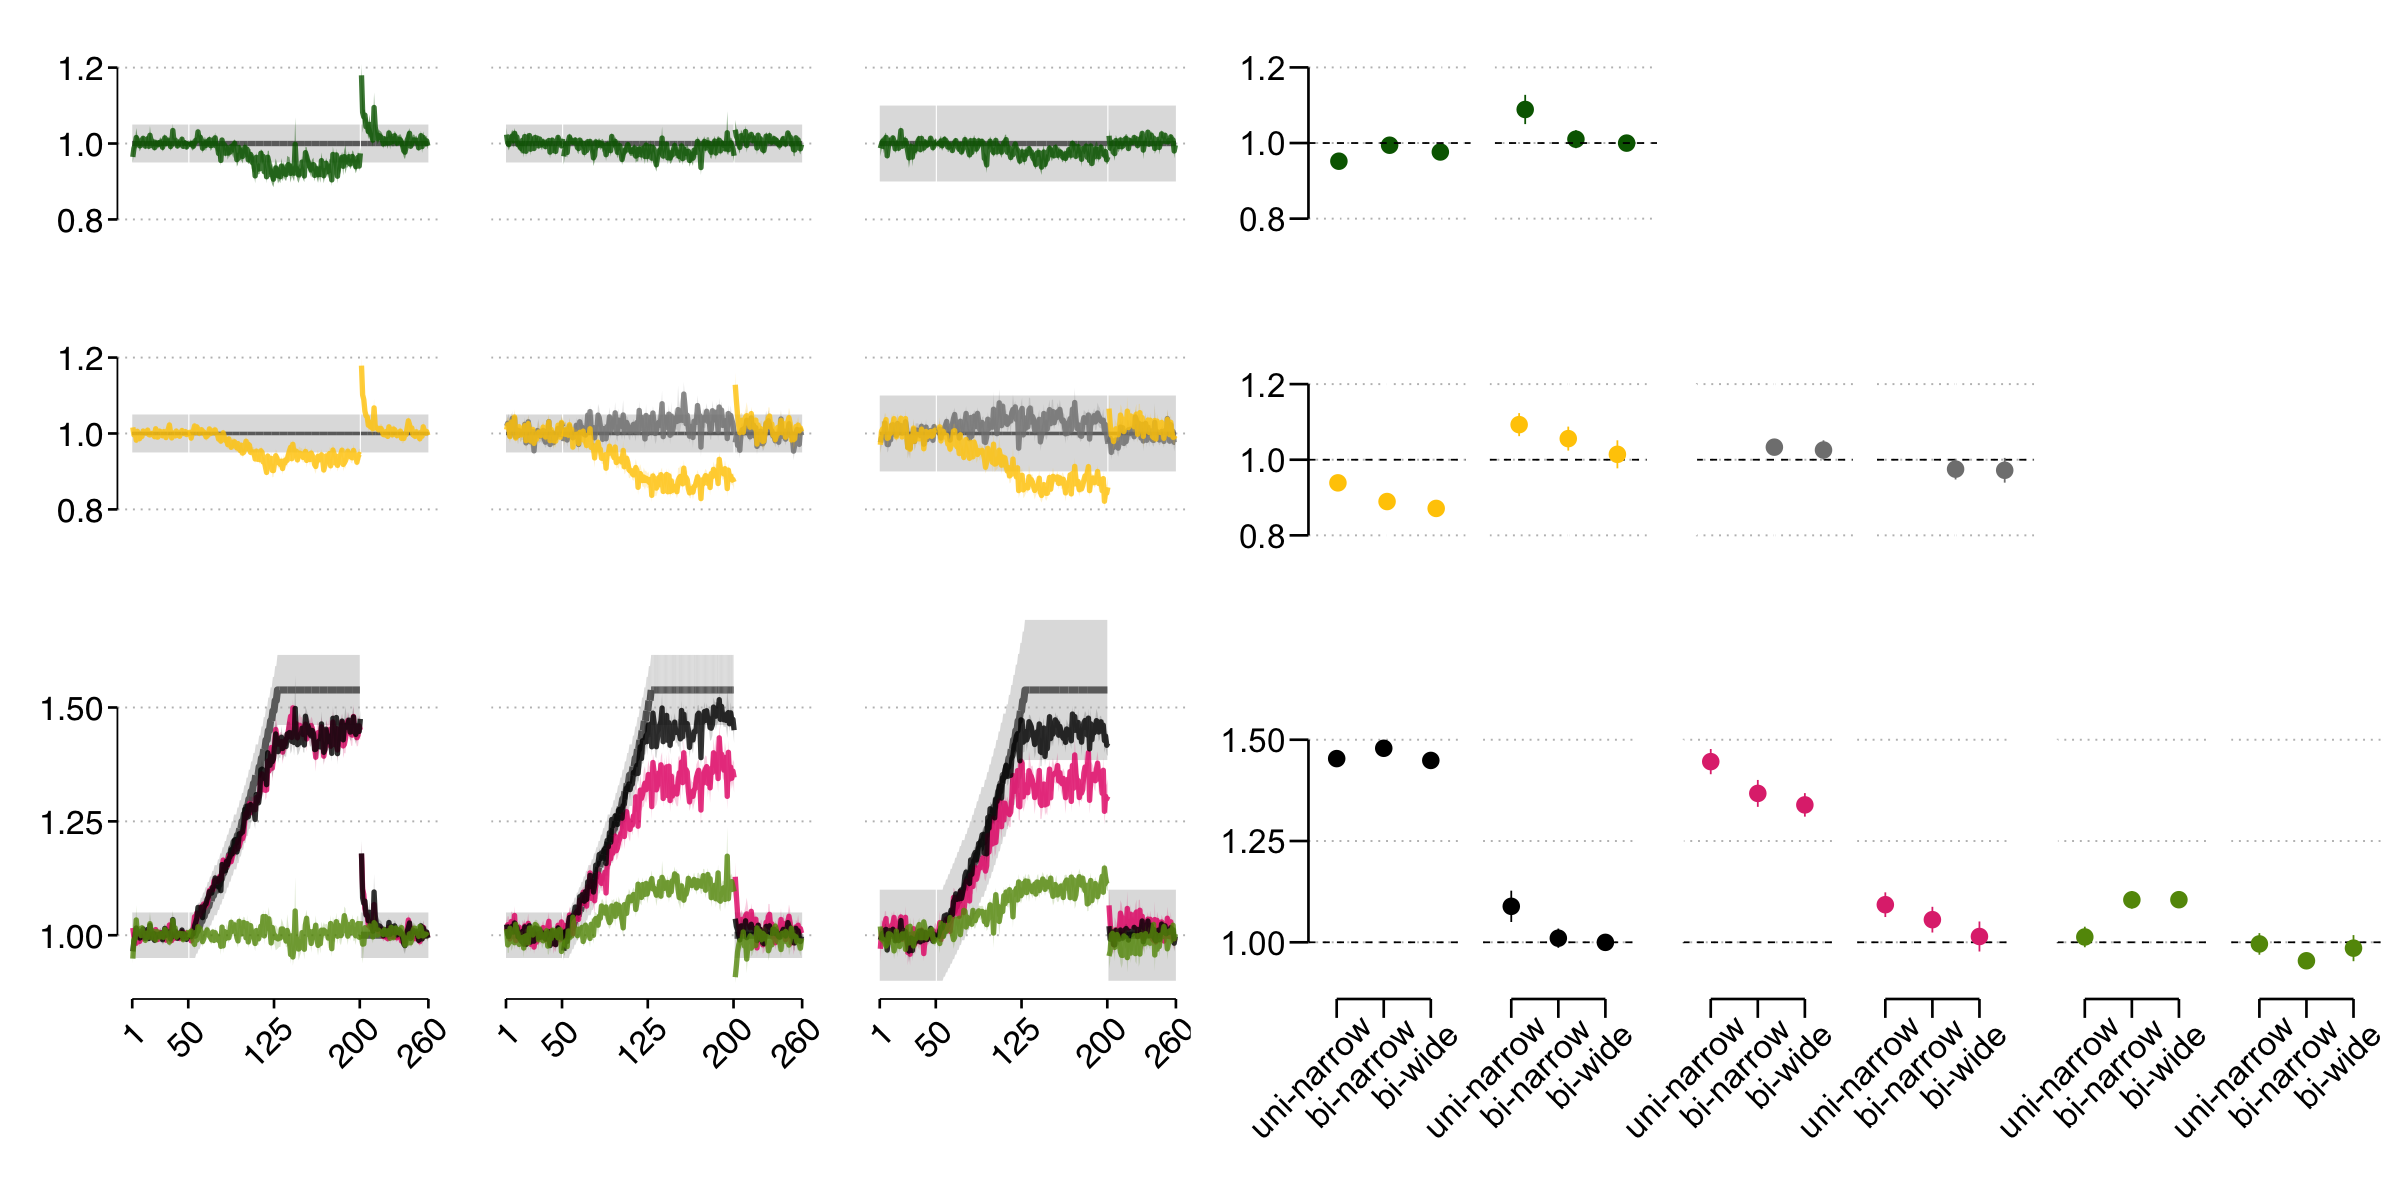

In [43]:
options(repr.plot.width=20, repr.plot.height=10)

Fig7 = Fig7_leftpanels  | Fig7_rightpanels + plot_layout(widths = c(11,9))
Fig7

# ggsave(file="GRP_F3_v3.svg", bg = "transparent", plot=F3_v3, width=20, height=10)

# Statistics

## Early speed: Bimanual-narrow group (Fig 2)
* people speed up their right hand relative to their left hand.
* initially people compensated for the perturbation by slowing down their left hand and speeding up their right hand.
* later people compensated only by speeding up their right hand with no signficant contributions from the left hand.
* only right hand showed significant positive aftereffects.

### define data

In [27]:
# define a constant `learnInt` = 1 in the summDat dataframe for offset comparisons
summDat$learnInt = 1
# data to run model on
mod1Dat = summDat %>% filter(tgtHtC=="narrow" & expGrp=="bimanual" & grp=="adults")

### run mixed model

In [28]:
# this model changes intercept to 1 by using offset(learnInt) - R/L ratio
mod1 = lmer(data = mod1Dat, EarlySlopeAdj_corr ~ 1 + offset(learnInt) + cond3 + (1|subj))

rmod1R = rlmer(data = mod1Dat, slopesR2_corr ~ 1 + offset(learnInt) + cond3 + (1|subj))

rmod1L = rlmer(data = mod1Dat, slopesL2_corr ~ 1 + offset(learnInt) + cond3 + (1|subj))

#--------------------------------------------------------------------------

table1 = tab_model(mod1, rmod1R, rmod1L, show.se = TRUE, show.ci = FALSE, show.stat = TRUE)
display_html(head(table1$page.complete))


Early Slope Adj corr 
 slopes R 2 corr 
 slopes L 2 corr 
 
 
 Predictors 
 Estimates 
 std. Error 
 Statistic 
 p 
 Estimates 
 std. Error 
 Statistic 
 p 
 Estimates 
 std. Error 
 Statistic 
 p 
 
 
 (Intercept) 
 -0.00 
 0.01 
 -0.27 
 0.790 
 1.01 
 0.05 
 20.30 
 <0.001 
 1.01 
 0.04 
 24.70 
 <0.001 
 
 
 cond3 [start.ramp] 
 0.03 
 0.01 
 2.93 
 0.003 
 0.01 
 0.02 
 0.28 
 0.778 
 -0.03 
 0.02 
 -1.15 
 0.249 
 
 
 cond3 [end.ramp] 
 0.13 
 0.01 
 12.05 
 <0.001 
 0.04 
 0.02 
 1.64 
 0.101 
 -0.08 
 0.02 
 -3.39 
 0.001 
 
 
 cond3 [start.plateau] 
 0.17 
 0.01 
 15.99 
 <0.001 
 0.08 
 0.02 
 3.08 
 0.002 
 -0.08 
 0.02 
 -3.48 
 0.001 
 
 
 cond3 [end.plateau] 
 0.20 
 0.01 
 18.40 
 <0.001 
 0.20 
 0.02 
 8.06 
 <0.001 
 -0.00 
 0.02 
 -0.08 
 0.936 
 
 
 cond3 [start.washout] 
 0.15 
 0.02 
 9.85 
 <0.001 
 0.11 
 0.04 
 3.12 
 0.002 
 -0.05 
 0.03 
 -1.41 
 0.158 
 
 
 cond3 [end.washout] 
 0.01 
 0.01 
 1.14 
 0.253 
 0.07 
 0.03 
 2.25 
 0.024 
 0.05 
 0.03 
 1.73 
 0.084 
 
 
 Random Effects 
 

 
 σ 2 
 0.02 
 0.09 
 0.08 
 

 
 τ 00 
 0.00 subj 
 0.04 subj 
 0.03 subj 

 
 ICC 
 0.13 
 0.33 
 0.26 

 
 N 
 22 subj 
 22 subj 
 22 subj 
 
 Observations 
 2567 
 2567 
 2567 
 
 
 Marginal R 2 / Conditional R 2 
 0.218 / 0.320 
 0.036 / 0.351 
 0.016 / 0.270

### do pairwise comparisons

In [29]:
emm1_RL = emmeans(mod1, ~ cond3)
emm1_L = emmeans(rmod1L, ~ cond3)
emm1_R = emmeans(rmod1R, ~ cond3)

allComps1 = list("Start Ramp - Baseline"    = c(-1, 1, 0, 0, 0, 0, 0), 
                 "End Ramp - Baseline"      = c(-1, 0, 1, 0, 0, 0, 0), 
                 "Start Plateau - Baseline" = c(-1, 0, 0, 1, 0, 0, 0),
                 "End Plateau - Baseline"   = c(-1, 0, 0, 0, 1, 0, 0),
                 "Start Washout - Baseline" = c(-1, 0, 0, 0, 0, 1, 0),
                 "End Washout - Baseline"   = c(-1, 0, 0, 0, 0, 0, 1))

In [30]:
display_markdown("**R/L scaling comparisons to baseline**")
comps1_RL = contrast(emm1_RL, method = allComps1, adjust = 'bonferroni')
summary(comps1_RL)

display_markdown("**L scaling comparisons to baseline**")
comps1_L  = contrast(emm1_L, method = allComps1, adjust = 'bonferroni')
summary(comps1_L)

display_markdown("**R scaling comparisons to baseline**")
comps1_R  = contrast(emm1_R, method = allComps1, adjust = 'bonferroni')
summary(comps1_R)

**R/L scaling comparisons to baseline**

,contrast,estimate,SE,df,t.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Start Ramp - Baseline,0.03107082,0.01062205,2539.101,2.925124,2.084226e-02
2,End Ramp - Baseline,0.12929780,0.01072811,2539.183,12.052247,8.614801e-32
3,Start Plateau - Baseline,0.17159790,0.01073304,2539.279,15.987814,4.070229e-54
4,End Plateau - Baseline,0.19659257,0.01068568,2539.135,18.397757,2.783649e-70
5,Start Washout - Baseline,0.15303638,0.01553466,2539.032,9.851289,1.021933e-21
6,End Washout - Baseline,0.01419302,0.01242207,2539.110,1.142565,1.000000e+00


**L scaling comparisons to baseline**

,contrast,estimate,SE,df,z.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Start Ramp - Baseline,-0.026855765,0.02326812,Inf,-1.15418719,1.000000000
2,End Ramp - Baseline,-0.079711763,0.02350051,Inf,-3.39191598,0.004164343
3,Start Plateau - Baseline,-0.081862791,0.02351140,Inf,-3.48183334,0.002987961
4,End Plateau - Baseline,-0.001891764,0.02340753,Inf,-0.08081861,1.000000000
5,Start Washout - Baseline,-0.048079921,0.03402933,Inf,-1.41289633,0.946117243
6,End Washout - Baseline,0.047008984,0.02721115,Inf,1.72756312,0.504399481


**R scaling comparisons to baseline**

,contrast,estimate,SE,df,z.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Start Ramp - Baseline,0.00696458,0.02470682,Inf,0.281889,1.000000e+00
2,End Ramp - Baseline,0.04099793,0.02495361,Inf,1.642966,6.023400e-01
3,Start Plateau - Baseline,0.07701027,0.02496520,Inf,3.084704,1.222528e-02
4,End Plateau - Baseline,0.20043370,0.02485487,Inf,8.064163,4.424354e-15
5,Start Washout - Baseline,0.11280204,0.03613339,Inf,3.121823,1.078410e-02
6,End Washout - Baseline,0.06513292,0.02889366,Inf,2.254229,1.450907e-01


## Early speed: Right hand uni vs bi-narrow (Fig 3)
* similar right hand scaling between uni and bi at the end of the learning block
* similar aftereffects in early washout
* larger scaling in uni compared to bi at the end of washout

### define data

In [31]:
mod2Dat = summDat %>% filter(tgtHtC=="narrow" & grp=="adults")

### run mixed model

In [32]:
rmod2R = rlmer(data = mod2Dat, slopesR2_corr ~ 1 + expGrp*cond3 + (1|subj))

#--------------------------------------------------------------------------

table2 = tab_model(rmod2R, show.se = TRUE, show.ci = FALSE, show.stat = TRUE)
display_html(head(table2$page.complete))

slopes R 2 corr 
 
 
 Predictors 
 Estimates 
 std. Error 
 Statistic 
 p 
 
 
 (Intercept) 
 1.00 
 0.06 
 16.19 
 <0.001 
 
 
 expGrp [bimanual] 
 0.00 
 0.09 
 0.05 
 0.958 
 
 
 cond3 [start.ramp] 
 0.08 
 0.03 
 2.85 
 0.004 
 
 
 cond3 [end.ramp] 
 0.12 
 0.03 
 4.29 
 <0.001 
 
 
 cond3 [start.plateau] 
 0.12 
 0.03 
 4.16 
 <0.001 
 
 
 cond3 [end.plateau] 
 0.24 
 0.03 
 8.42 
 <0.001 
 
 
 cond3 [start.washout] 
 0.15 
 0.04 
 3.49 
 <0.001 
 
 
 cond3 [end.washout] 
 0.23 
 0.03 
 7.07 
 <0.001 
 
 
 expGrp [bimanual] × cond3 [start.ramp] 
 -0.07 
 0.04 
 -1.82 
 0.068 
 
 
 expGrp [bimanual] × cond3 [end.ramp] 
 -0.08 
 0.04 
 -1.98 
 0.048 
 
 
 expGrp [bimanual] × cond3 [start.plateau] 
 -0.04 
 0.04 
 -0.98 
 0.325 
 
 
 expGrp [bimanual] × cond3 [end.plateau] 
 -0.04 
 0.04 
 -0.92 
 0.356 
 
 
 expGrp [bimanual] × cond3 [start.washout] 
 -0.03 
 0.06 
 -0.56 
 0.574 
 
 
 expGrp [bimanual] × cond3 [end.washout] 
 -0.16 
 0.05 
 -3.57 
 <0.001 
 
 
 Random Effects 
 

 
 σ 2 
 0.11 
 

 
 τ 00 subj 
 0.07 

 
 ICC 
 0.38 

 
 N subj 
 43 
 
 Observations 
 4944 
 
 
 Marginal R 2 / Conditional R 2 
 0.032 / 0.396

### do pairwise comparisons

In [33]:
emm2 = emmeans(rmod2R, ~ expGrp * cond3)

# Define contrasts for difference-in-difference (DiD)
allComps2 = list("(Bi-Uni) Start Ramp - (Bi-Uni) Baseline"    = c(1, -1, -1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0),
                 "(Bi-Uni) End Ramp - (Bi-Uni) Baseline"      = c(1, -1, 0, 0, -1, 1, 0, 0, 0, 0, 0, 0, 0, 0),
                 "(Bi-Uni) Start Plateau - (Bi-Uni) Baseline" = c(1, -1, 0, 0, 0, 0, -1, 1, 0, 0, 0, 0, 0, 0),
                 "(Bi-Uni) End Plateau - (Bi-Uni) Baseline"   = c(1, -1, 0, 0, 0, 0, 0, 0, -1, 1, 0, 0, 0, 0),
                 "(Bi-Uni) Start Washout - (Bi-Uni) Baseline" = c(1, -1, 0, 0, 0, 0, 0, 0, 0, 0, -1, 1, 0, 0),
                 "(Bi-Uni) End Washout - (Bi-Uni) Baseline"   = c(1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 1))

comps2_R = contrast(emm2, method = allComps2, adjust = "bonferroni")

display_markdown("**R scaling DiD comparisons**")
summary(comps2_R)

**R scaling DiD comparisons**

,contrast,estimate,SE,df,z.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,(Bi-Uni) Start Ramp - (Bi-Uni) Baseline,-0.07141414,0.03915934,Inf,-1.8236808,0.409202065
2,(Bi-Uni) End Ramp - (Bi-Uni) Baseline,-0.07833170,0.03958296,Inf,-1.9789249,0.286946804
3,(Bi-Uni) Start Plateau - (Bi-Uni) Baseline,-0.03918845,0.03980432,Inf,-0.9845274,1.000000000
4,(Bi-Uni) End Plateau - (Bi-Uni) Baseline,-0.03656445,0.03962490,Inf,-0.9227644,1.000000000
5,(Bi-Uni) Start Washout - (Bi-Uni) Baseline,-0.03261995,0.05804115,Inf,-0.5620141,1.000000000
6,(Bi-Uni) End Washout - (Bi-Uni) Baseline,-0.16378242,0.04583380,Inf,-3.5733979,0.002114272


## Early speed: Bi-wide vs Bi-narrow (Fig 4)

### define data

In [34]:
mod3Dat = summDat %>% filter(expGrp=="bimanual" & grp=="adults")

### run mixed model

In [ ]:
mod3RL = lmer(data = mod3Dat, EarlySlopeAdj_corr ~ 1 + tgtHtC*cond3 + (1|subj))
rmod3R = rlmer(data = mod3Dat, slopesR2_corr ~ 1 + tgtHtC*cond3 + (1|subj))
rmod3L = rlmer(data = mod3Dat, slopesL2_corr ~ 1 + tgtHtC*cond3 + (1|subj))

#--------------------------------------------------------------------------

table3 = tab_model(mod3, rmod3R, rmod3L, show.se = TRUE, show.ci = FALSE, show.stat = TRUE)
display_html(head(table3$page.complete))

### do pairwise comparisons

In [ ]:
emm3_RL = suppressMessages(emmeans(mod3RL, ~ tgtHtC * cond3))
emm3_L = suppressMessages(emmeans(rmod3L, ~ tgtHtC * cond3))
emm3_R = suppressMessages(emmeans(rmod3R, ~ tgtHtC * cond3))

# Define contrasts for difference-in-difference (DiD)
allComps3 = list("(3-6) Baseline - (3-6) Start Ramp"    = c(1, -1, -1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0),
                 "(3-6) Baseline - (3-6) End Ramp"      = c(1, -1, 0, 0, -1, 1, 0, 0, 0, 0, 0, 0, 0, 0),
                 "(3-6) Baseline - (3-6) Start Plateau" = c(1, -1, 0, 0, 0, 0, -1, 1, 0, 0, 0, 0, 0, 0),
                 "(3-6) Baseline - (3-6) End Plateau"   = c(1, -1, 0, 0, 0, 0, 0, 0, -1, 1, 0, 0, 0, 0),
                 "(3-6) Baseline - (3-6) Start Washout" = c(1, -1, 0, 0, 0, 0, 0, 0, 0, 0, -1, 1, 0, 0),
                 "(3-6) Baseline - (3-6) End Washout"   = c(1, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 1))


In [ ]:
display_markdown("**R/L scaling DiD comparisons**")
comps3_RL = contrast(emm3_RL, method = allComps3, adjust = 'bonferroni')
summary(comps3_RL)

display_markdown("**L scaling DiD comparisons**")
comps3_L  = contrast(emm3_L, method = allComps3, adjust = 'bonferroni')
summary(comps3_L)

display_markdown("**R scaling DiD comparisons**")
comps3_R  = contrast(emm3_R, method = allComps3, adjust = 'bonferroni')
summary(comps3_R)

## Success rates: Across the 3 groups (Fig 5)

### define data

In [51]:
# since rates calculated across trials, use summDat2 averages
mod4Dat = summDat2 %>% filter(grp=="adults")

### run linear model

In [52]:
mod4Succ = lm(data = mod4Dat, 
              succRate~ 1 + cond3 * OmniGrp )
# summary(mod4Succ) %>% tidy()
anova(mod4Succ)
glance(mod4Succ)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
cond3,6,51658.948,8609.8247,24.107605,2.682770e-24
OmniGrp,2,87931.577,43965.7885,123.104699,3.245510e-42
cond3:OmniGrp,12,4635.358,386.2799,1.081588,3.740932e-01
Residuals,392,139999.442,357.1414,NA,NA


r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.507435,0.4823042,18.89819,20.1917,1.817807e-48,20,-1789.079,3622.159,3710.675,139999.4,392,413


### do pairwise comparisons

In [53]:
emmeans(mod4Succ, ~OmniGrp|cond3*OmniGrp) %>% pairs() %>% 
tidy() #%>% filter(adj.p.value<0.05)

cond3,term,contrast,null.value,estimate,std.error,df,statistic,adj.p.value
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
baseline,OmniGrp,(uni-narrow) - (bi-narrow),0,23.0146705,5.765452,392,3.99182417,2.305907e-04
baseline,OmniGrp,(uni-narrow) - (bi-wide),0,0.5787037,6.271210,392,0.09227943,9.953163e-01
baseline,OmniGrp,(bi-narrow) - (bi-wide),0,-22.4359668,6.209271,392,-3.61330152,9.942032e-04
start.ramp,OmniGrp,(uni-narrow) - (bi-narrow),0,26.9600665,5.765452,392,4.67614103,1.200535e-05
start.ramp,OmniGrp,(uni-narrow) - (bi-wide),0,-0.9268912,6.271210,392,-0.14780101,9.880293e-01
start.ramp,OmniGrp,(bi-narrow) - (bi-wide),0,-27.8869577,6.209271,392,-4.49118095,2.774361e-05
end.ramp,OmniGrp,(uni-narrow) - (bi-narrow),0,32.9670061,5.765452,392,5.71802632,6.408136e-08
end.ramp,OmniGrp,(uni-narrow) - (bi-wide),0,-4.5394472,6.271210,392,-0.72385509,7.495018e-01
end.ramp,OmniGrp,(bi-narrow) - (bi-wide),0,-37.5064533,6.209271,392,-6.04039603,1.069906e-08


## Displacement: Across the 3 groups (Fig 7)

### define data

In [46]:
mod5Dat = summDat2 %>% filter(grp=="adults")

### !! set the depedent variable here:
* Using LM because disp measures are much less variable across trials compared to early speed (see Figs)
* Because all the variables we tested here are using the same model, we use the same code below

In [58]:
# set displacement dependent variable
DV_list = c("Py_corr_mn",  "Ry_corr_mn",       "Ly_corr_mn", 
            "sRy_corr_mn", "totDispR_corr_mn", "tilt_comp_mn")

DV = DV_list[6]

In [59]:
mod5 = lm(data = mod5Dat, formula = as.formula(paste(DV, "~ 1 + cond3 * OmniGrp")))
# summary(mod5) %>% tidy()
anova(mod5)
glance(mod5)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
cond3,6,0.5208430,0.08680716,52.37456,3.025220e-47
OmniGrp,2,0.1228110,0.06140549,37.04862,1.830911e-15
cond3:OmniGrp,12,0.2653214,0.02211012,13.34000,4.035203e-23
Residuals,392,0.6497125,0.00165743,NA,NA


r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.583167,0.5619,0.04071154,27.42123,3.870272e-62,20,746.8684,-1449.737,-1361.221,0.6497125,392,413


### do pairwise comparisons

In [60]:
emmeans(mod5, ~OmniGrp|cond3) %>% pairs() %>% 
tidy() %>% filter(cond3%in%cc) #%>% filter(adj.p.value<0.05)

cond3,term,contrast,null.value,estimate,std.error,df,statistic,adj.p.value
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
end.plateau,OmniGrp,(uni-narrow) - (bi-narrow),0,-0.0917077943,0.01242026,392,-7.38372377,0.000000e+00
end.plateau,OmniGrp,(uni-narrow) - (bi-wide),0,-0.0920230507,0.01350980,392,-6.81157960,9.268197e-11
end.plateau,OmniGrp,(bi-narrow) - (bi-wide),0,-0.0003152564,0.01337636,392,-0.02356817,9.996938e-01
start.washout,OmniGrp,(uni-narrow) - (bi-narrow),0,0.0416164824,0.01242026,392,3.35069241,2.541614e-03
start.washout,OmniGrp,(uni-narrow) - (bi-wide),0,0.0104347430,0.01350980,392,0.77238346,7.202033e-01
start.washout,OmniGrp,(bi-narrow) - (bi-wide),0,-0.0311817394,0.01337636,392,-2.33110751,5.275714e-02


~~
**END OF PRIMARY ANALYSES**
~~

## Additional Checks/Analyses

### diagnostics function

In [454]:
# Function to perform LMER diagnostics using base R
lmer_diagnostics <- function(model,data, threshold = 0.1) {
  
  # Ensure the model is of class 'lmerMod'
  if (!inherits(model, "lmerMod")) {
    stop("The input must be an lmer object.")
  }
  
  # Extract residuals and fitted values
  residuals <- resid(model)
  fitted_values <- fitted(model)
  
  # Extract Subject ID and Trial number (or other relevant variables)
  subject_id <- as.character(attr(model@frame, "row.names"))  # Get Subject IDs from data
  trial_number <- data$trial  # Assuming 'Trial' is a column in the original dataset passed to 'lmer'
  
  # Create a combined data frame for Cook's Distance and Trial labels
  cooks_dist <- cooks.distance(model)
  cooks_data <- data.frame(cooks_distance = cooks_dist, subject_id = subject_id, trial_number = trial_number)
  cooks_data$highlight <- cooks_data$cooks_distance > threshold  # Mark observations exceeding the threshold
  
  # Set up the plotting area (3 rows and 2 columns)
  par(mfrow = c(2, 3))  
  
  # 1. Residuals vs Fitted Plot
  plot(fitted_values, residuals, xlab = "Fitted Values", ylab = "Residuals",
       main = "Residuals vs Fitted", pch = 16, col = rgb(0, 0, 0, 0.5))
  abline(h = 0, col = "red")
  lines(lowess(fitted_values, residuals), col = "blue", l6 = 2)
  
  # 2. Q-Q Plot of Residuals
  qqnorm(residuals, main = "Q-Q Plot of Residuals")
  qqline(residuals, col = "red")
  
  # 3. Histogram of Residuals
  hist(residuals, main = "Histogram of Residuals", xlab = "Residuals", 
       col = "blue", border = "black", breaks = 30)
  
  # 4. ACF of Residuals
  acf(residuals, main = "ACF of Residuals")
  
  # 5. Cook's Distance Plot (with labels for observations exceeding threshold)
  plot(cooks_data$cooks_distance, type = "h", main = "Cook's Distance", 
       xlab = "Observation", ylab = "Cook's Distance", col = "red")
  abline(h = threshold, col = "blue", l6 = 2)  # Add threshold line

    # Add labels for observations exceeding the threshold, but only if they are not empty
highlight_indices <- which(cooks_data$highlight)

# Check if there are any labels to display
if (length(highlight_indices) > 0) {
  # Make sure to only add text where both Subject ID and Trial Number are non-empty
  valid_labels <- !is.na(cooks_data$subject_id[highlight_indices]) & 
                  !is.na(cooks_data$trial_number[highlight_indices]) &
                  cooks_data$subject_id[highlight_indices] != "" &
                  cooks_data$trial_number[highlight_indices] != ""
  
  # Only add text for valid labels (non-empty and non-NA)
  valid_highlight_indices <- highlight_indices[valid_labels]
  
  if (length(valid_highlight_indices) > 0) {
    text(
      x = valid_highlight_indices, 
      y = cooks_data$cooks_distance[valid_highlight_indices], 
      labels = paste("Subj: ", cooks_data$subject_id[valid_highlight_indices], 
                     "\nTrial: ", cooks_data$trial_number[valid_highlight_indices]),
      pos = 4, cex = 0.7, col = "black"
    )
  }
}
  
  # 6. Random Effects Plot (if applicable)
  random_effects <- ranef(model)
  
  if (length(random_effects) > 0) {
    # Extract random effects values and plot them
    random_effects_values <- unlist(random_effects)
    # hist(random_effects_values, main = "Random Effects", 
    #      xlab = "Random Effects", col = "green", border = "black", breaks = 30)
    
    # 7. Q-Q Plot of Random Effects
    qqnorm(random_effects_values, main = "Q-Q Plot of Random Effects")
    qqline(random_effects_values, col = "green")
  }
  
  # Reset the plotting layout
  par(mfrow = c(1, 1))
}


### mod1 hands LME diag

2 highly influential data point in L, thus robust

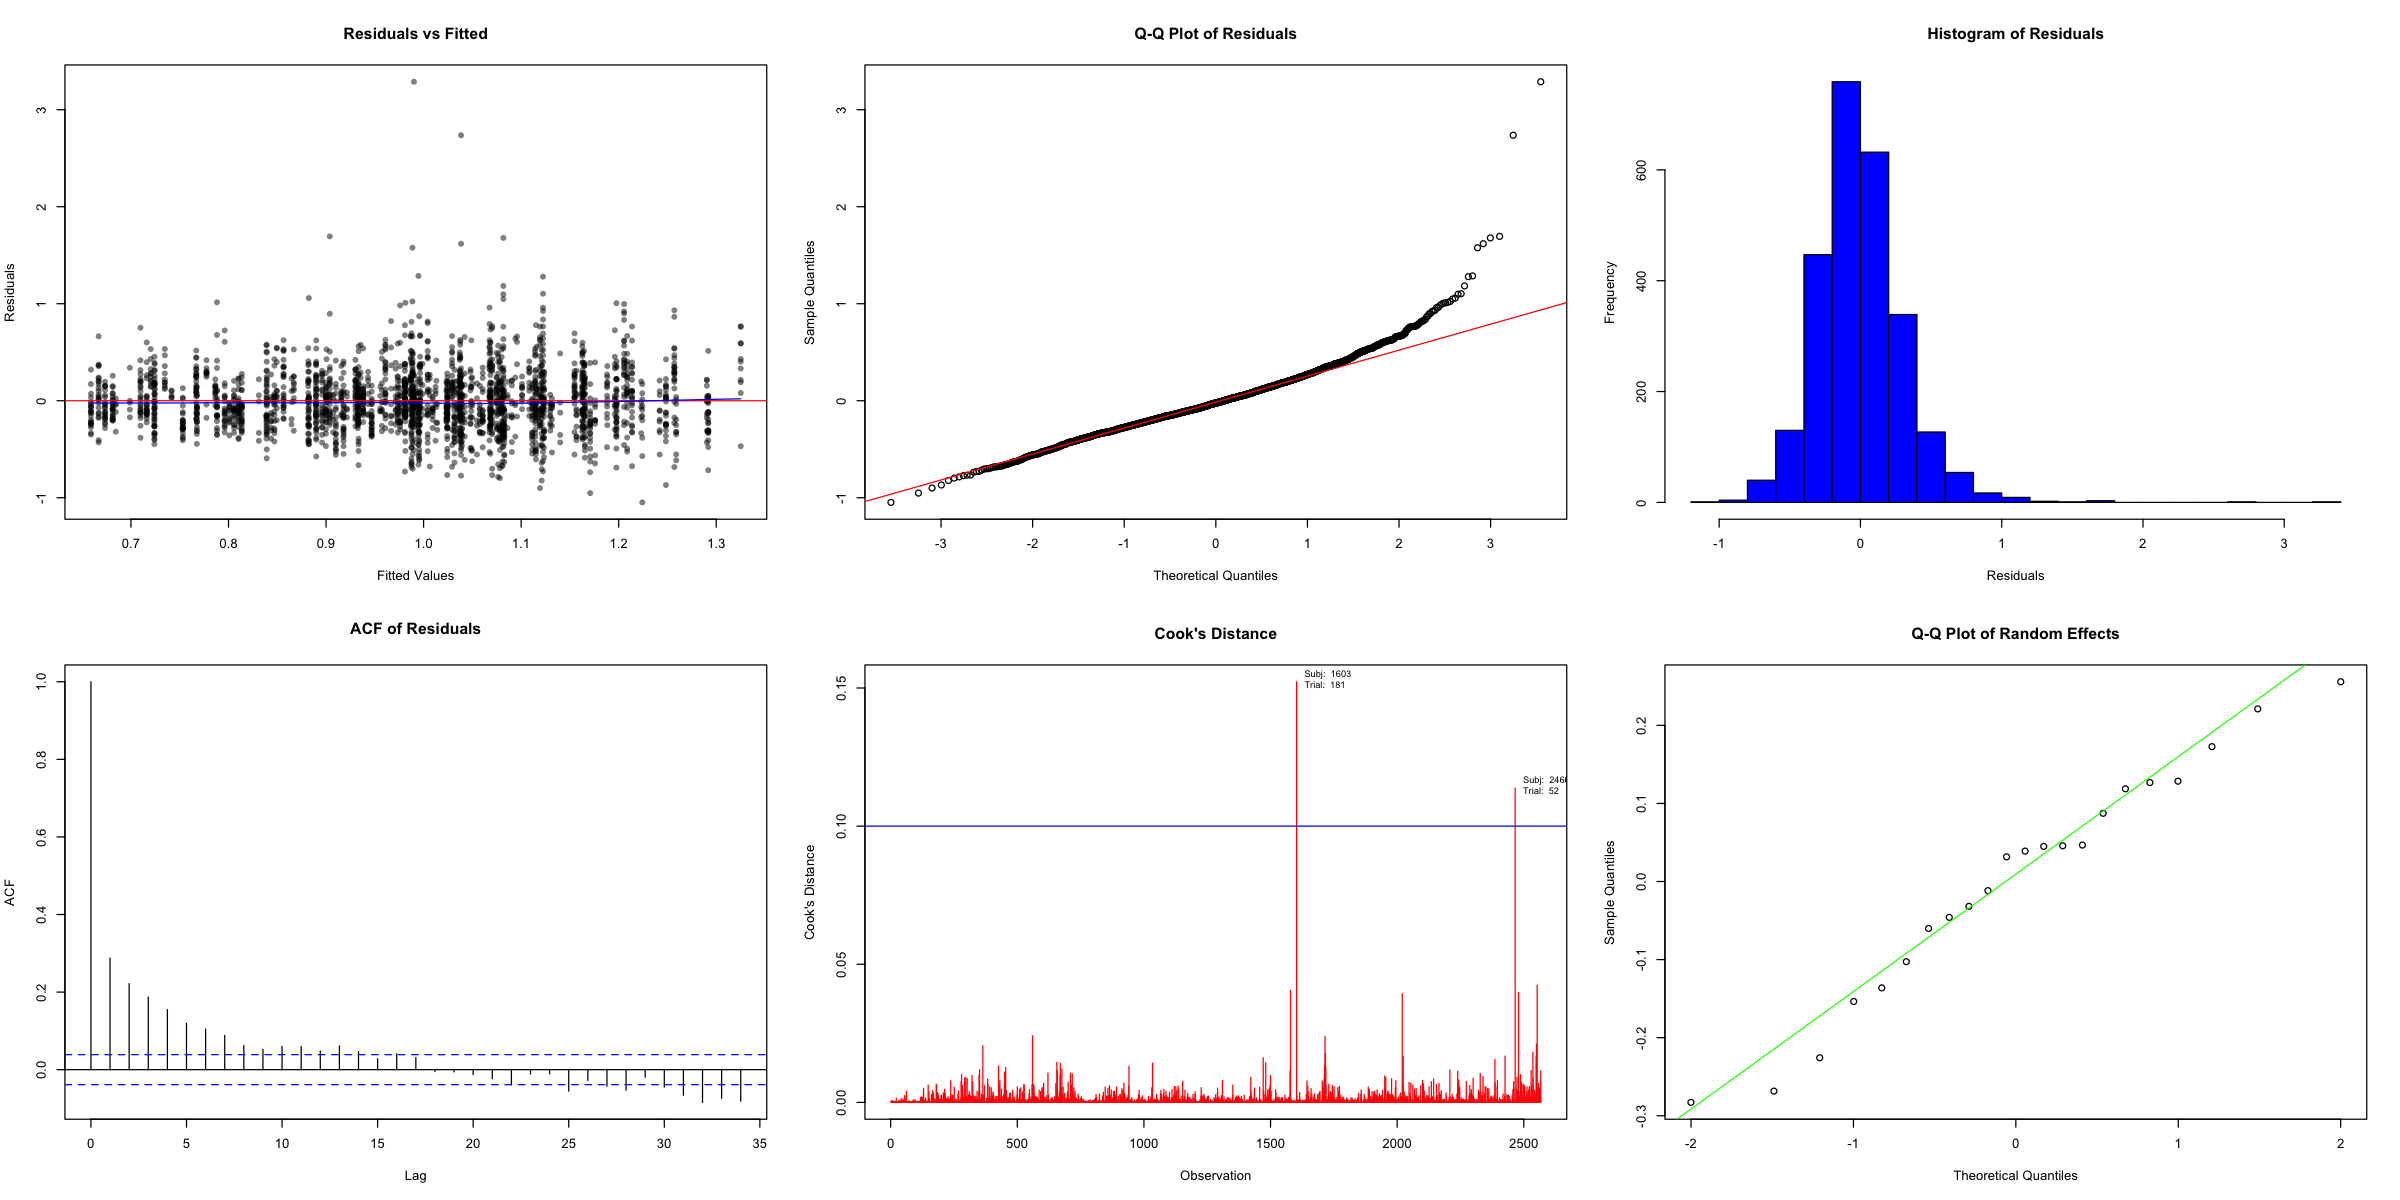

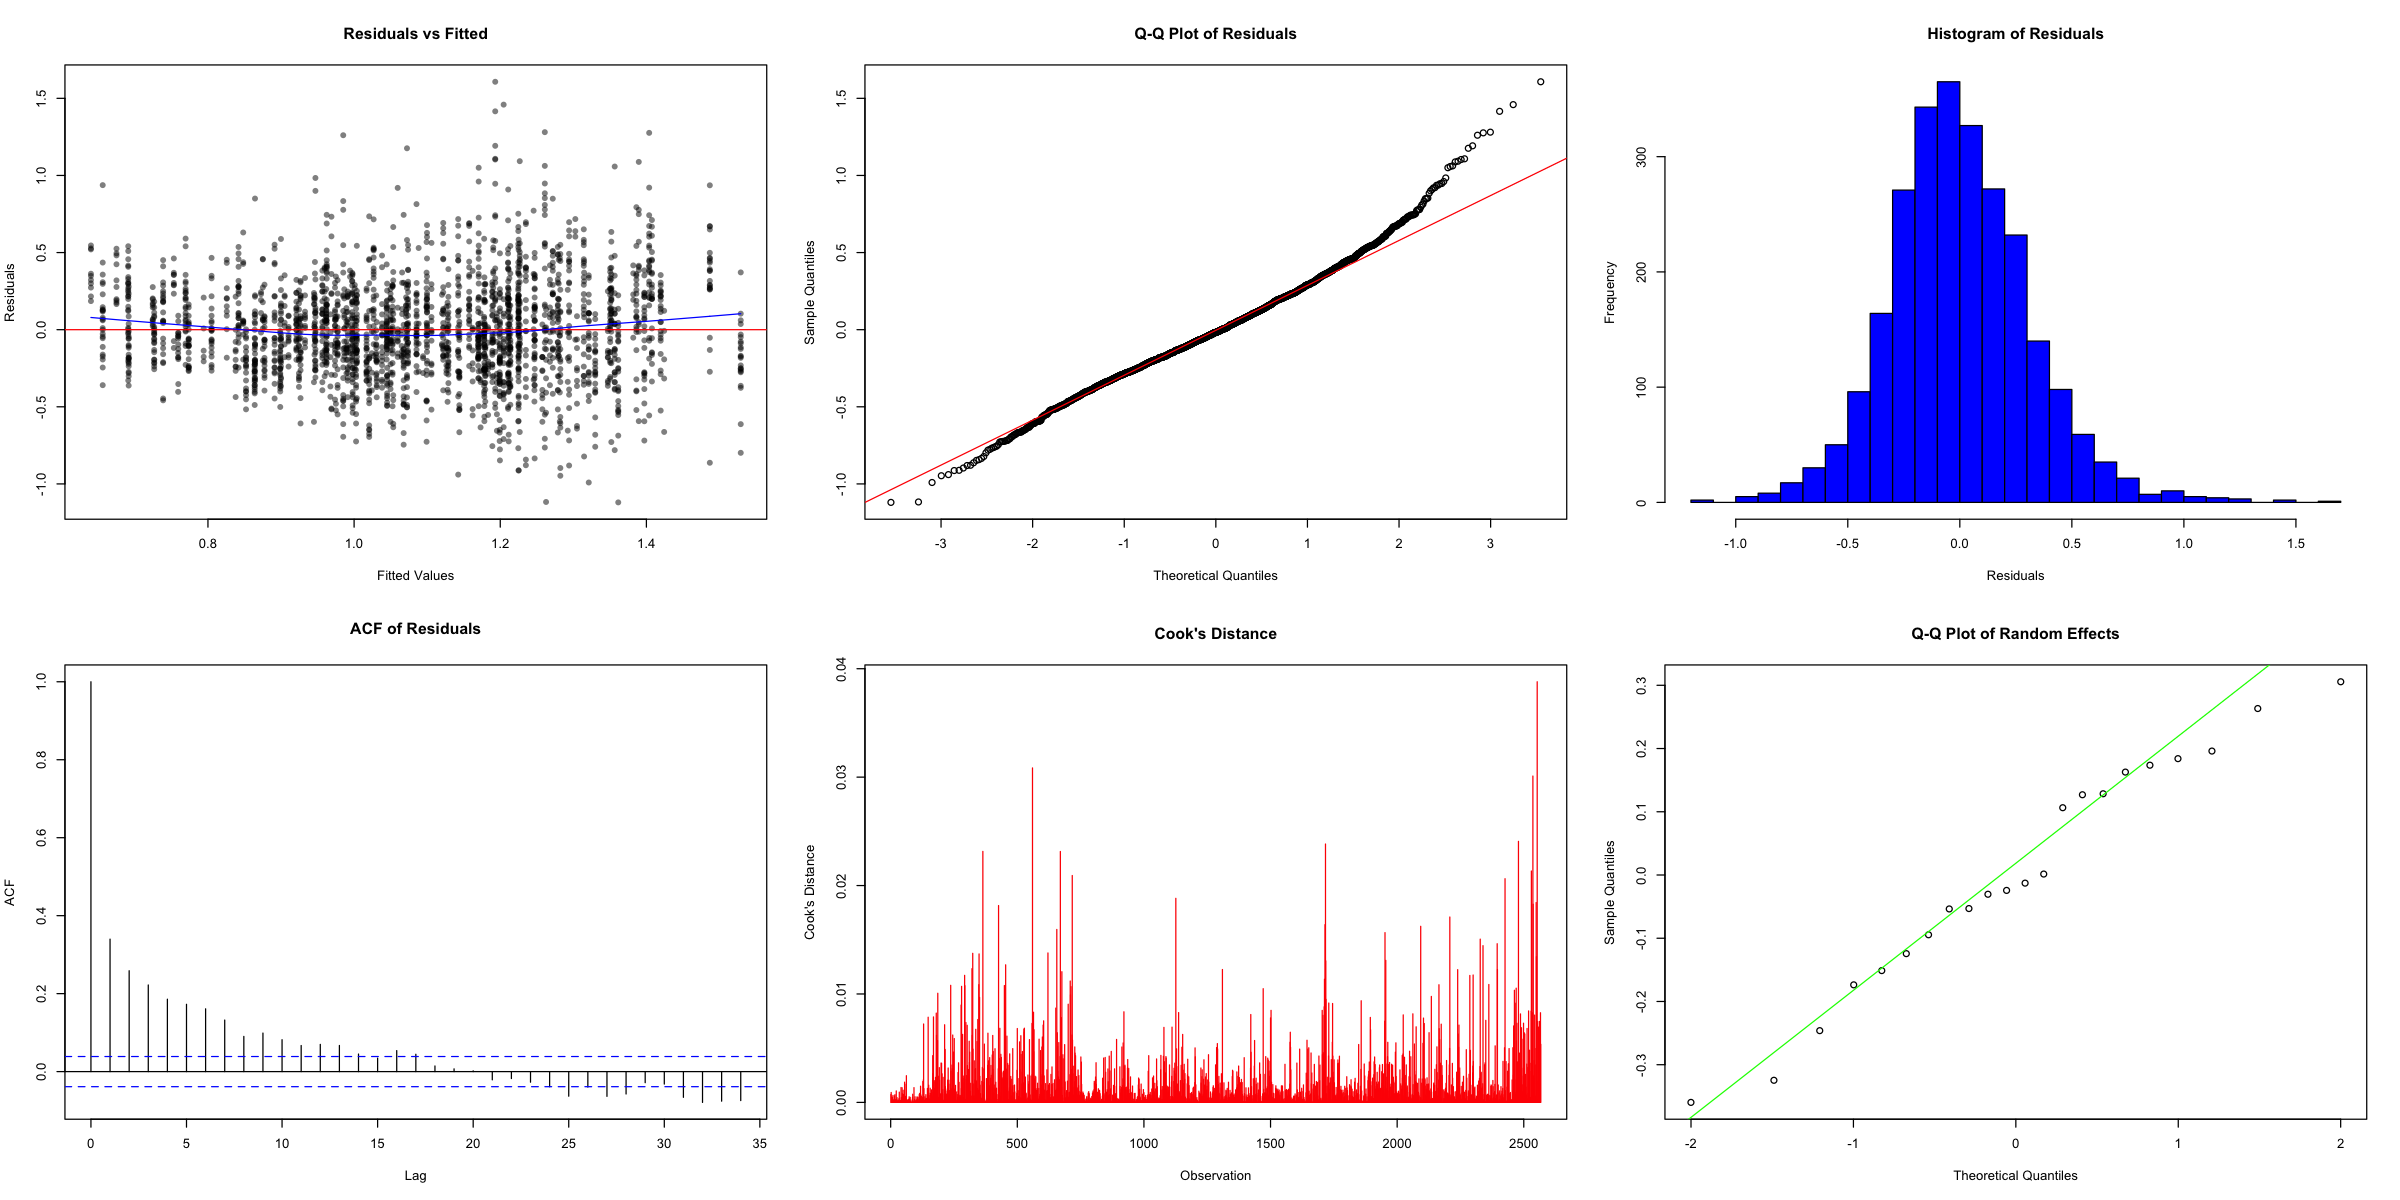

In [464]:
mod1R = lmer(data = mod1Dat, slopesR2_corr ~ 1 + offset(learnInt) + cond3 + (1|subj))
mod1L = lmer(data = mod1Dat, slopesL2_corr ~ 1 + offset(learnInt) + cond3 + (1|subj))

display_markdown("2 highly influential data point in L, thus robust")
lmer_diagnostics(mod1L, mod1Dat)
lmer_diagnostics(mod1R, mod1Dat)

#### mod1 hands robust LME diag 
* see weightings

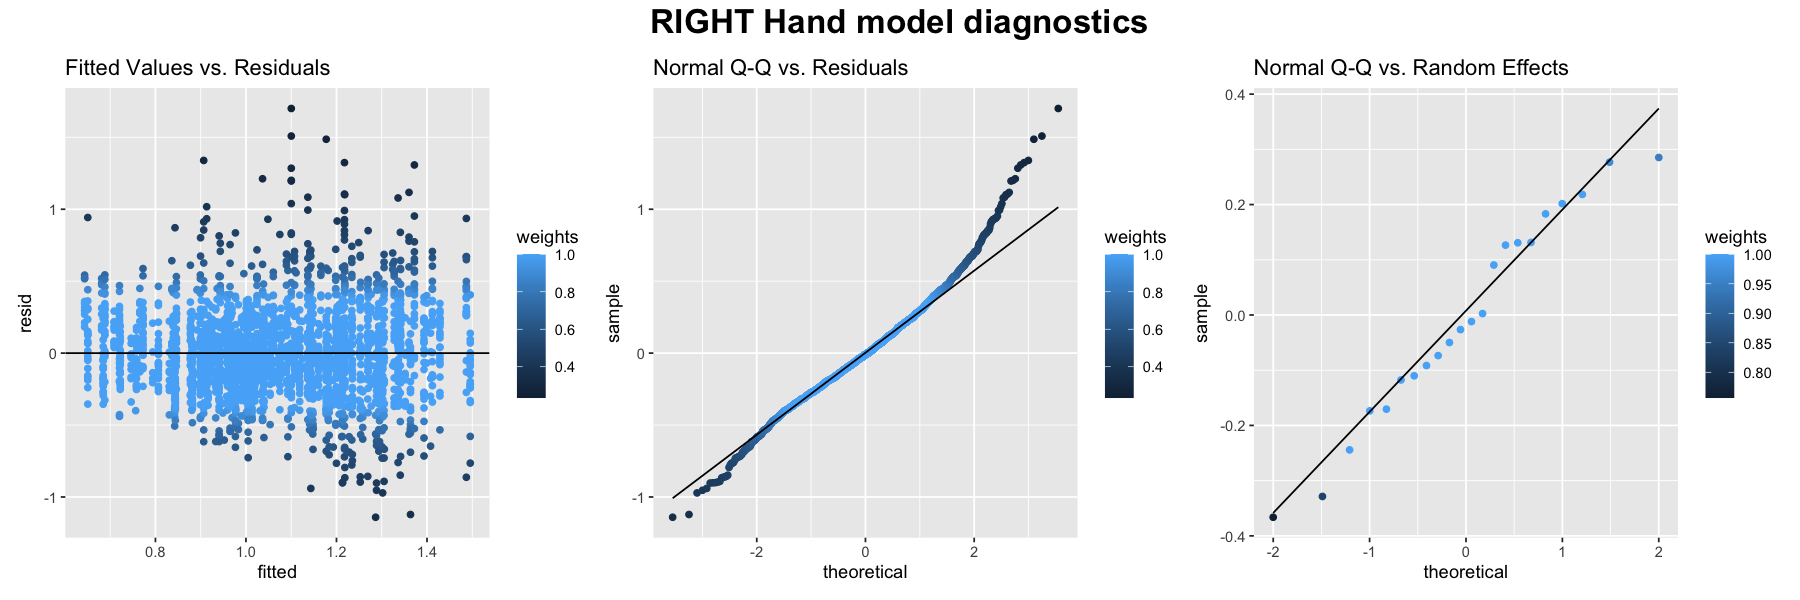

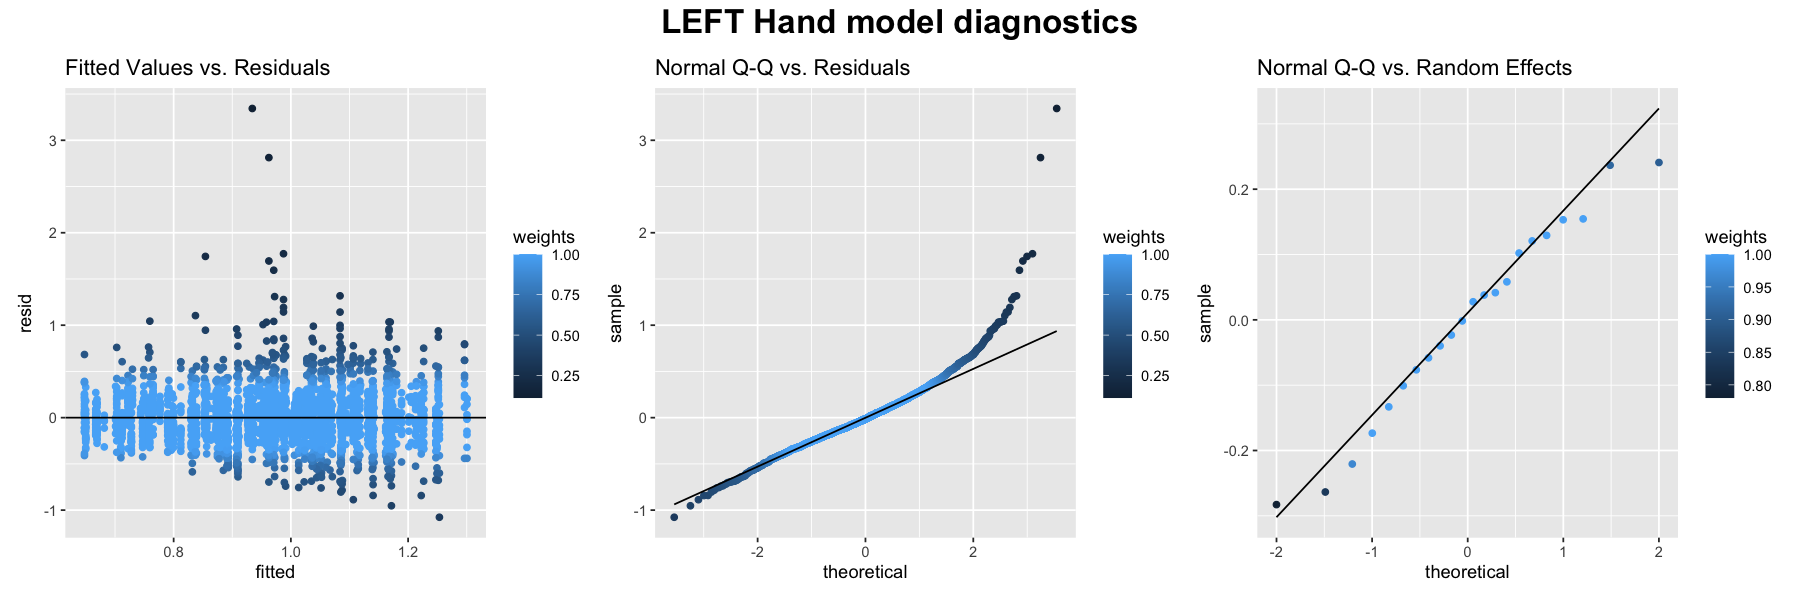

In [465]:
options(repr.plot.width=15, repr.plot.height=5)
pl_mod1R = plot(rmod1R)
pl_mod1L = plot(rmod1L)

comb_RIGHT = pl_mod1R[[1]] + pl_mod1R[[2]] + pl_mod1R[[3]] 
comb_RIGHT + plot_annotation(
  title = "RIGHT Hand model diagnostics",
  theme = theme(
    plot.title = element_text(face = "bold", size = 20, hjust = 0.5, color = "black"),
  )
)
comb_LEFT = pl_mod1L[[1]] + pl_mod1L[[2]] + pl_mod1L[[3]] 
comb_LEFT + plot_annotation(
  title = "LEFT Hand model diagnostics",
  theme = theme(
    plot.title = element_text(face = "bold", size = 20, hjust = 0.5, color = "black"),
  )
)

### mod2 R hand LME diag

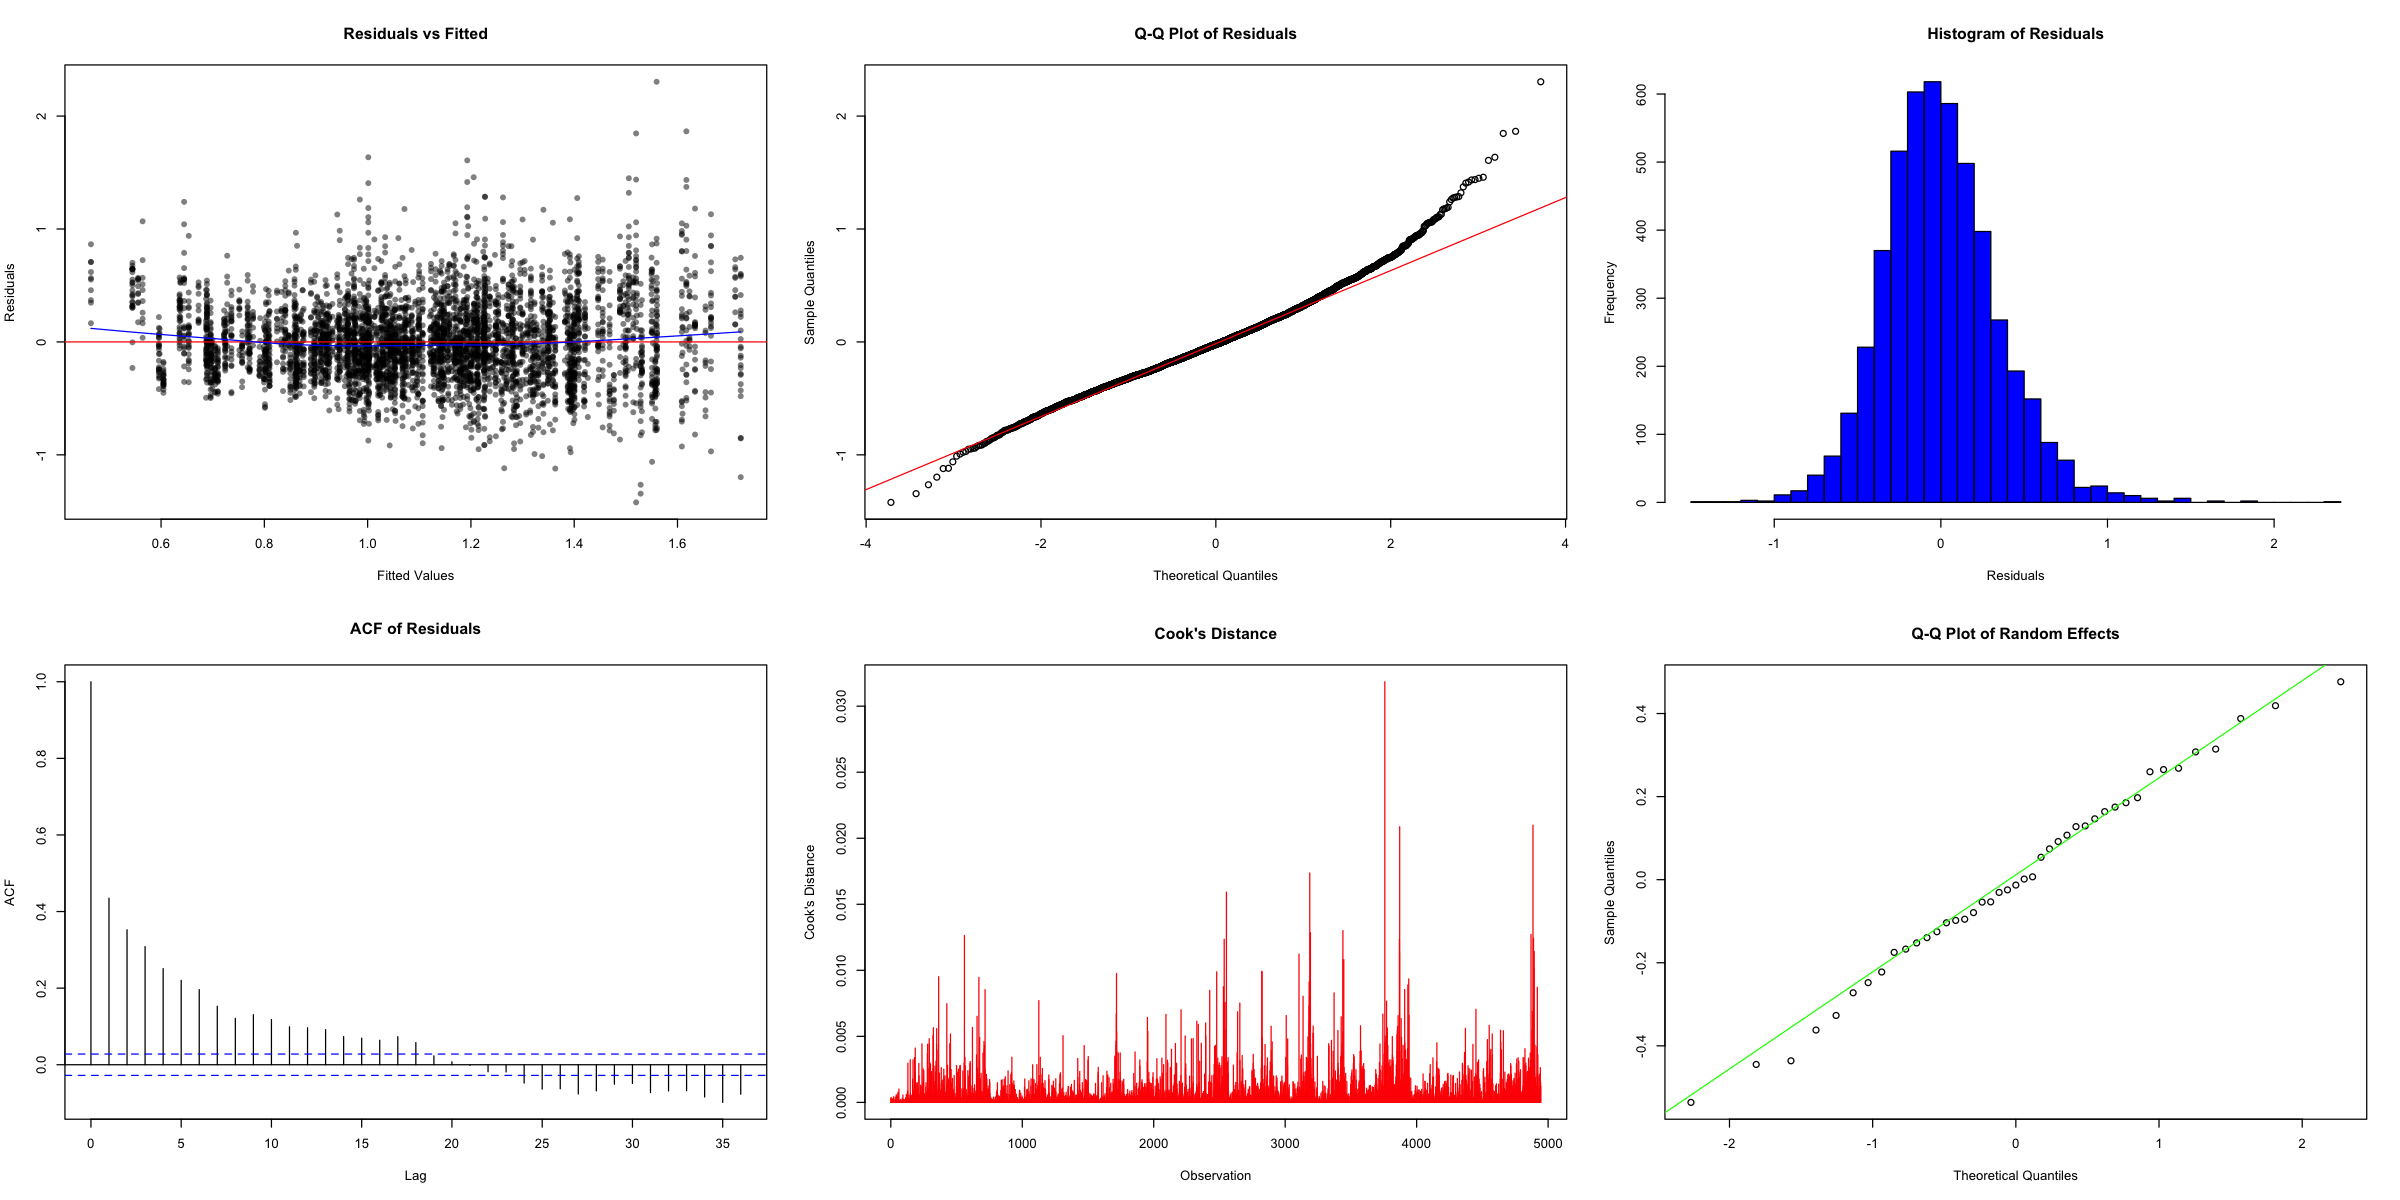

In [456]:
mod2R = lmer(data = mod2Dat, slopesR2_corr ~ 1 + expGrp*cond3 + (1|subj))
lmer_diagnostics(mod2R, mod2Dat)

#### mod 2 R hand robust LME diag

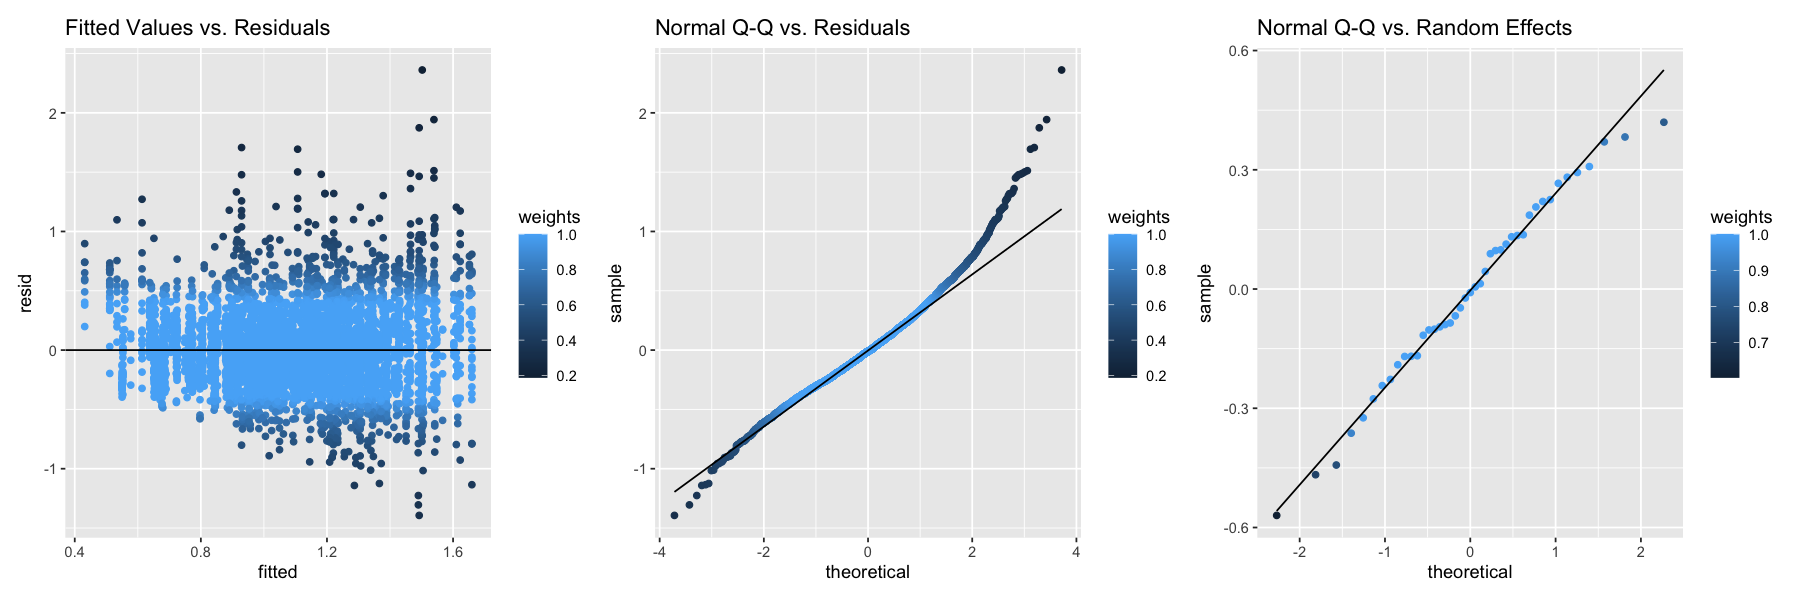

In [466]:
pl_mod2R = plot(rmod2R)
pl_mod2R[[1]] + pl_mod2R[[2]] + pl_mod2R[[3]] 

### mod3 hands LME diag

1 highly influential data point in R, thus robust

1 highly influential data point in L, thus robust

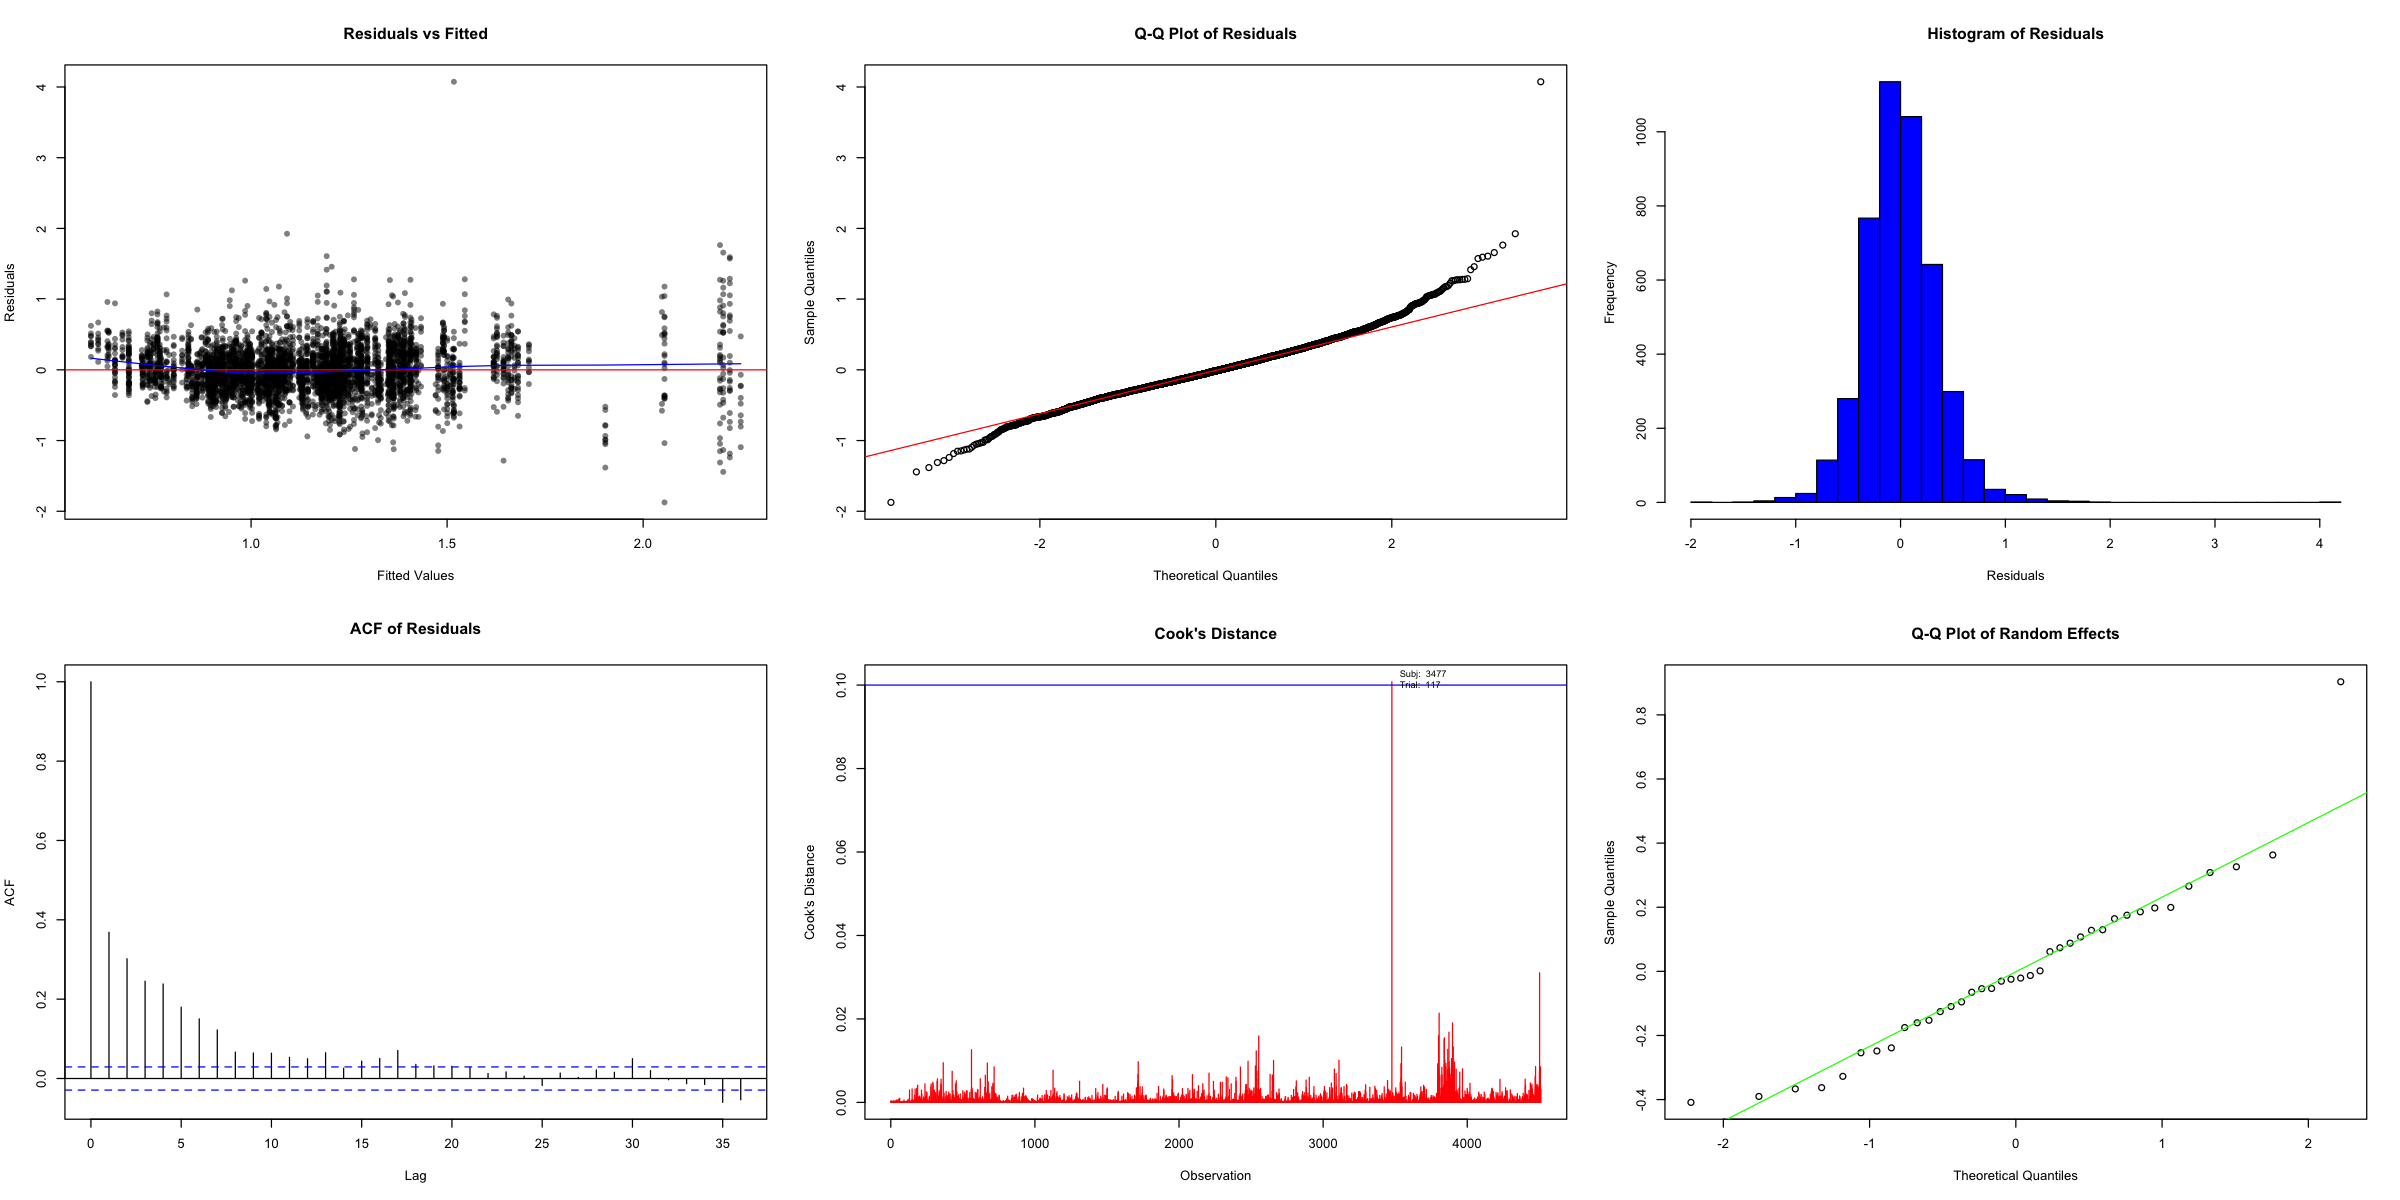

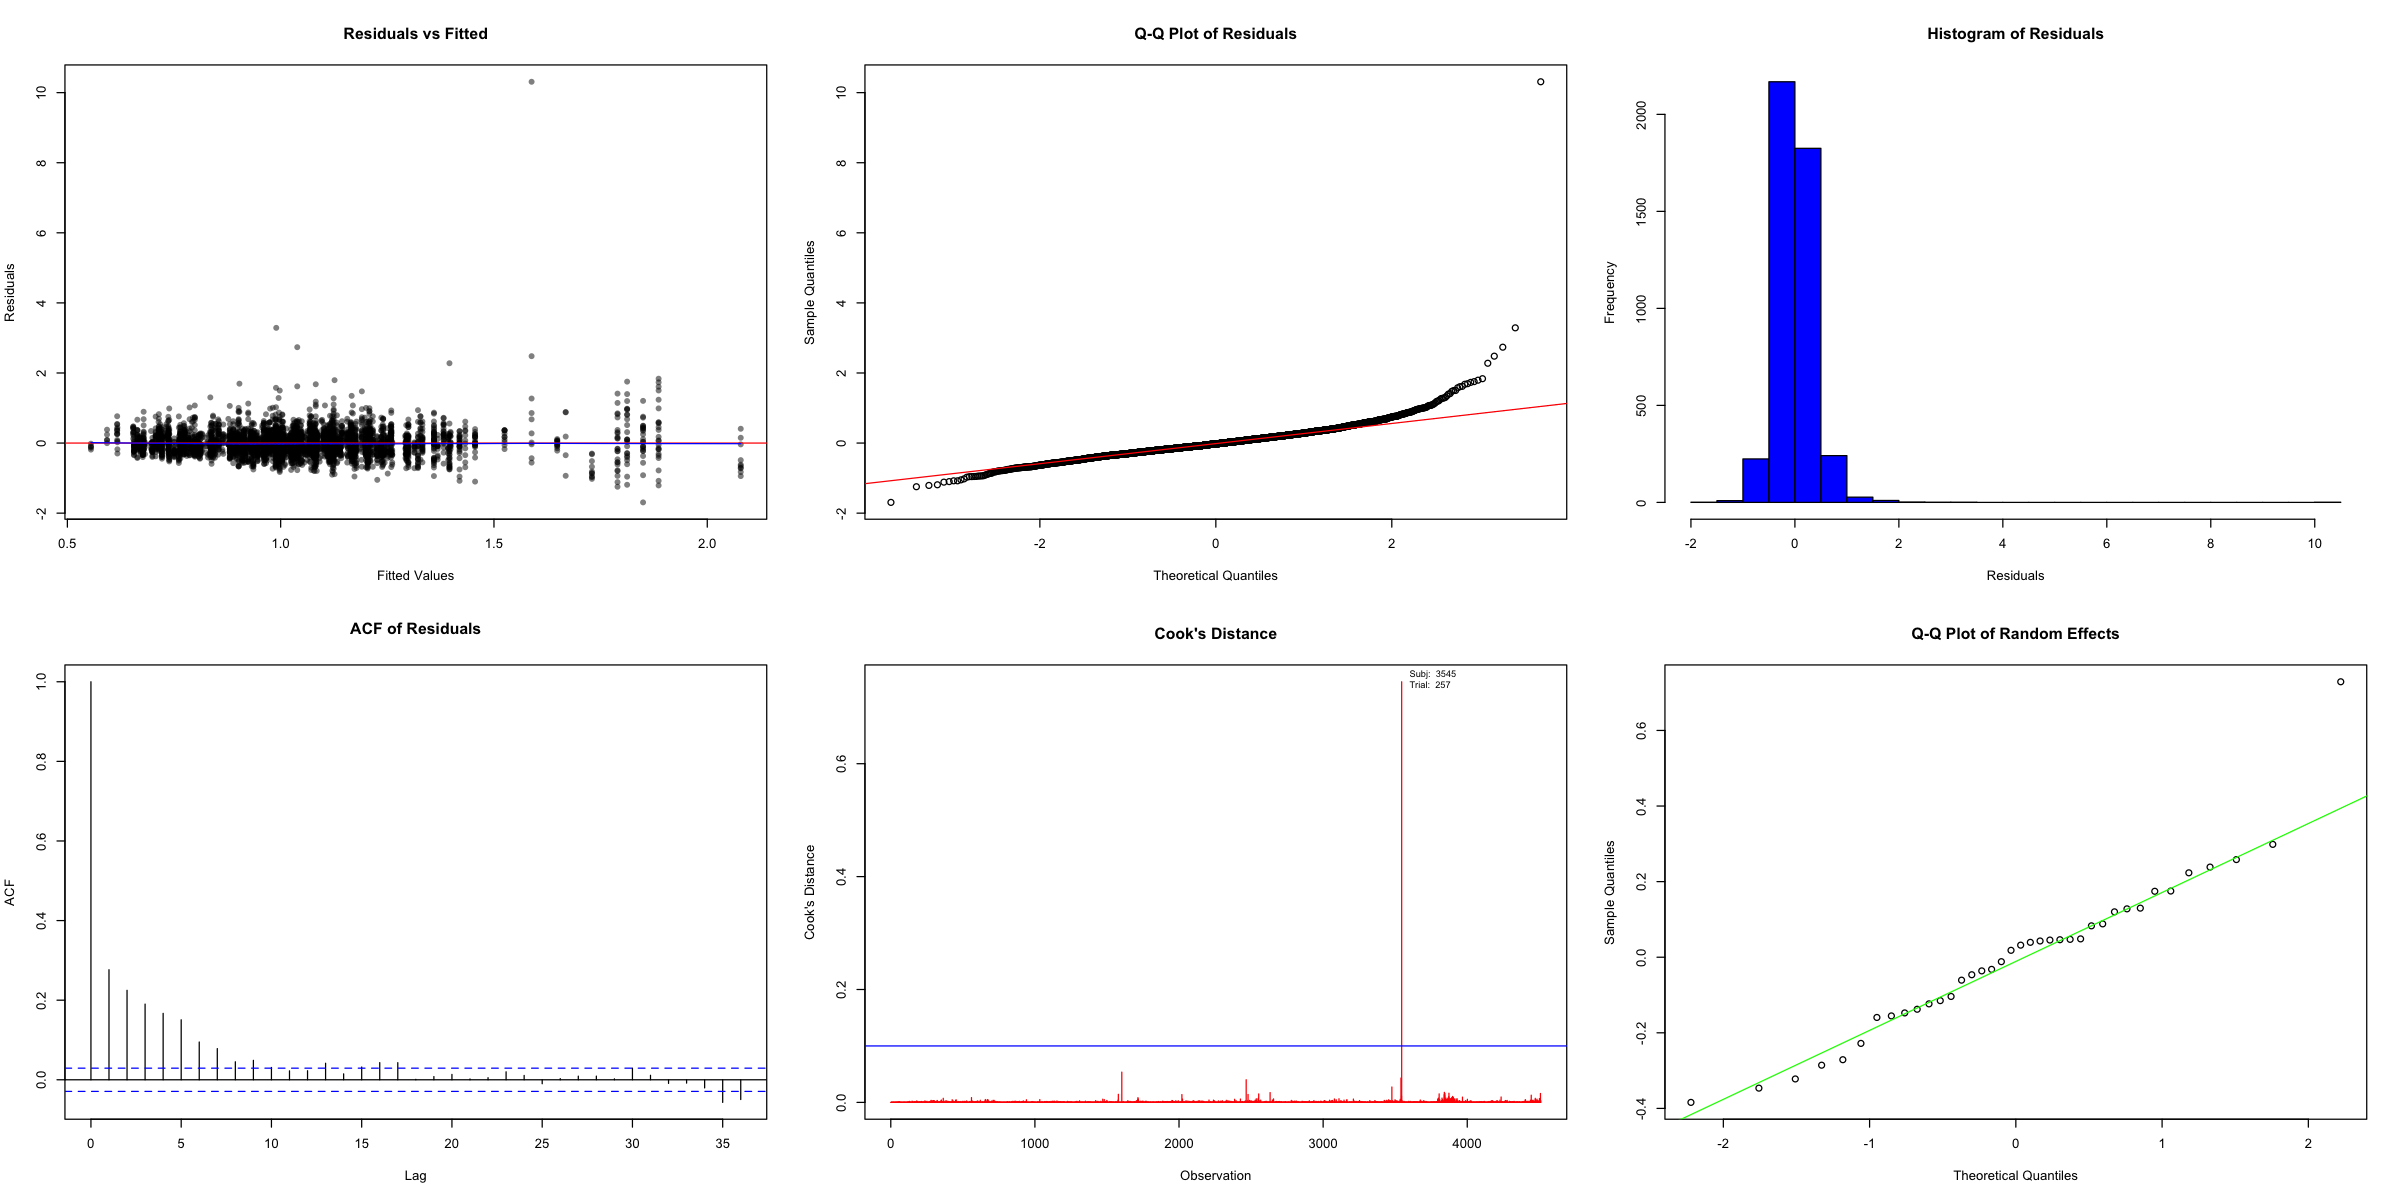

In [462]:
mod3R = lmer(data = mod3Dat,
    slopesR2_corr ~ 1 + tgtHtC*cond3 + (1|subj))
mod3L = lmer(data = mod3Dat,
    slopesL2_corr ~ 1 + tgtHtC*cond3 + (1|subj))

display_markdown("1 highly influential data point in R, thus robust")
lmer_diagnostics(mod3R, mod3Dat)
display_markdown("1 highly influential data point in L, thus robust")
lmer_diagnostics(mod3L, mod3Dat)


#### mod 3 hands robust LME diag

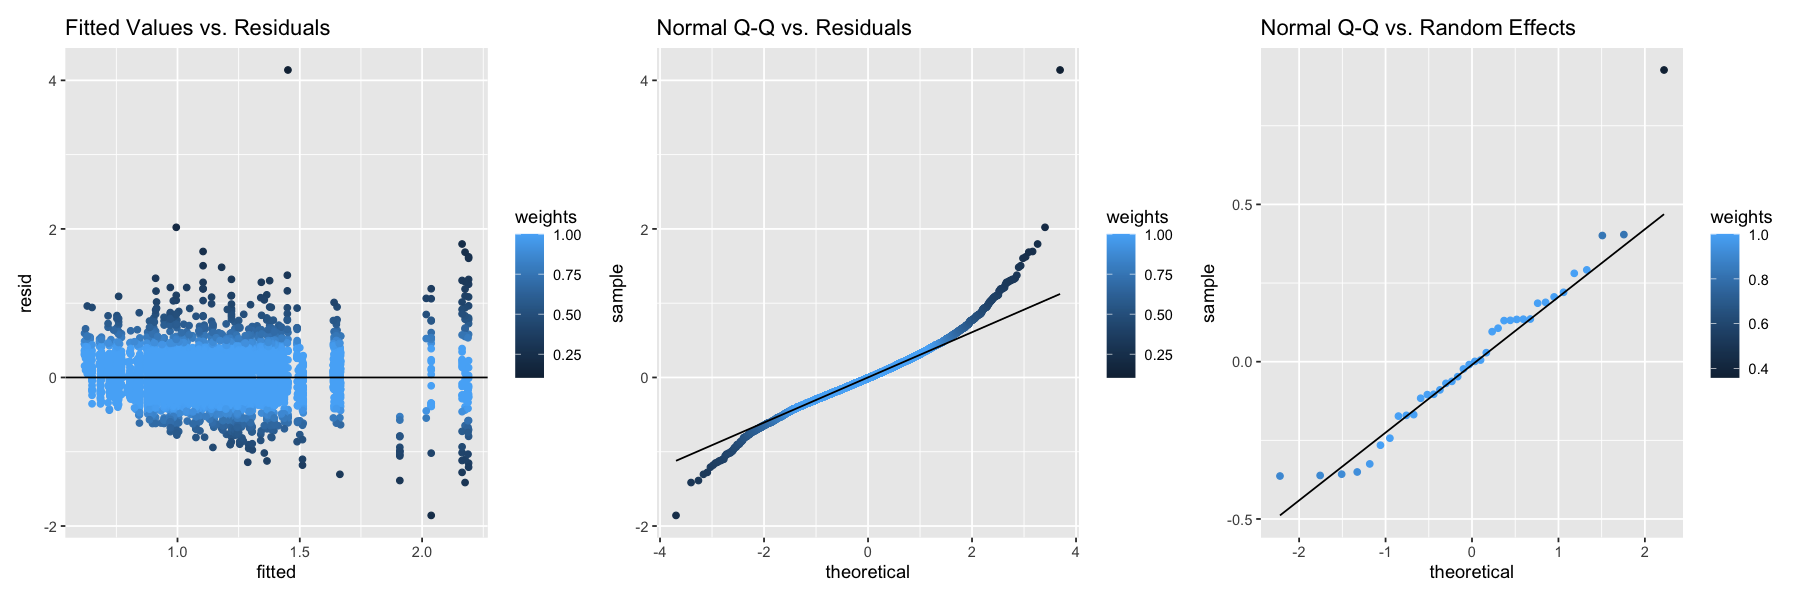

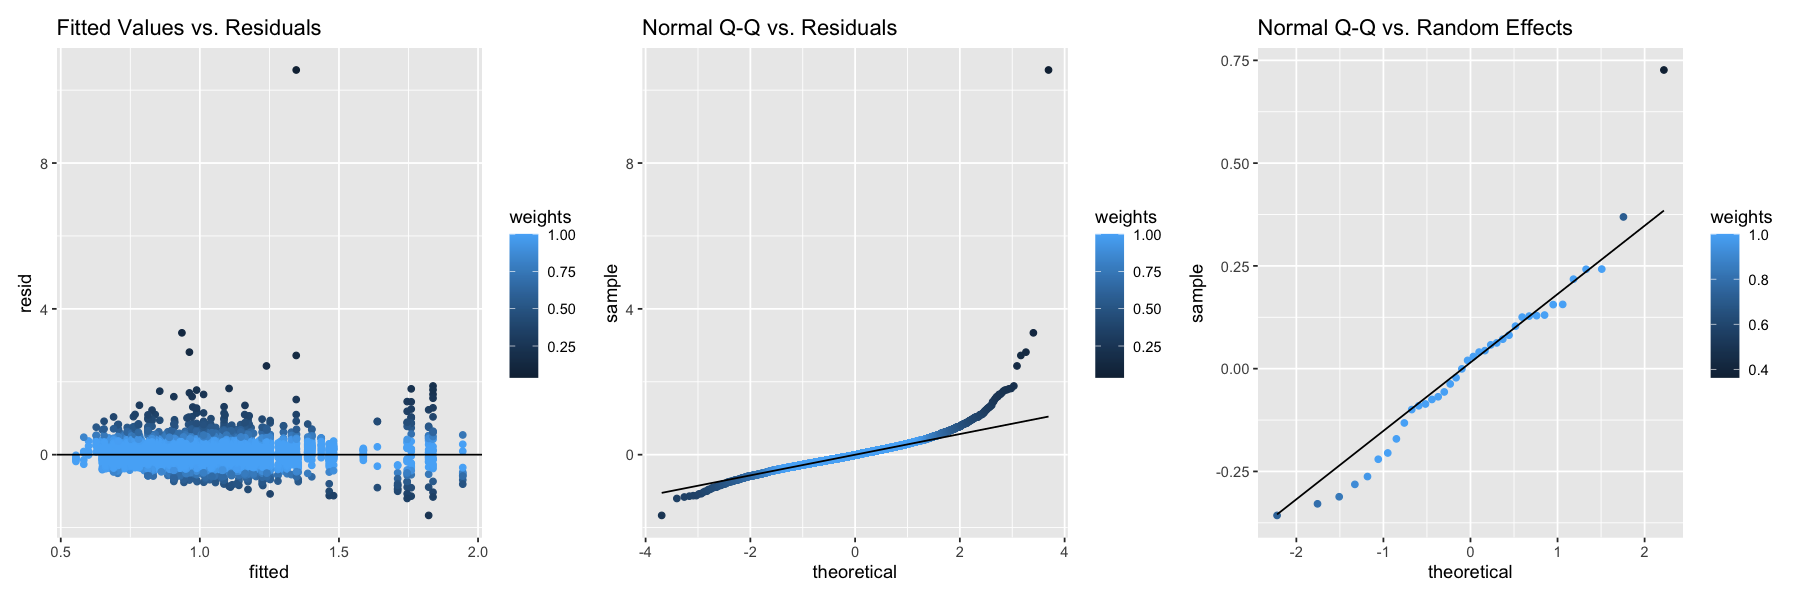

In [467]:
pl_mod3R = plot(rmod3R)
pl_mod3L = plot(rmod3L)

pl_mod3R[[1]] + pl_mod3R[[2]] + pl_mod3R[[3]] 
pl_mod3L[[1]] + pl_mod3L[[2]] + pl_mod3L[[3]] 

***
# END OF ANALYSIS
***

In [452]:
display_markdown("### Packages in use: ")
search()

display_markdown("### R version & citation: ")
citation()

display_markdown("### Specific package to cite: EMMEANS")
citation("emmeans")

### Packages in use: 

[1] ".GlobalEnv"           "package:emmeans"      "package:forcats"     
 [4] "package:viridis"      "package:viridisLite"  "package:svglite"     
 [7] "package:grid"         "package:car"          "package:carData"     
[10] "package:ggstance"     "package:ggthemes"     "package:ggExtra"     
[13] "package:plotly"       "package:sjPlot"       "package:sjstats"     
[16] "package:influence.ME" "package:broom"        "package:robustlmm"   
[19] "package:lme4"         "package:Matrix"       "package:lemon"       
[22] "package:performance"  "package:lubridate"    "package:purrr"       
[25] "package:boot"         "package:tidyr"        "package:dplyr"       
[28] "package:patchwork"    "package:ggpubr"       "package:IRdisplay"   
[31] "package:ggplot2"      "package:repr"         "jupyter:irkernel"    
[34] "package:stats"        "package:graphics"     "package:grDevices"   
[37] "package:utils"        "package:datasets"     "package:methods"     
[40] "Autoloads"            "package:base"

### R version & citation: 

To cite R in publications use:

  R Core Team (2024). _R: A Language and Environment for Statistical
  Computing_. R Foundation for Statistical Computing, Vienna, Austria.
  <https://www.R-project.org/>.

A BibTeX entry for LaTeX users is

  @Manual{,
    title = {R: A Language and Environment for Statistical Computing},
    author = {{R Core Team}},
    organization = {R Foundation for Statistical Computing},
    address = {Vienna, Austria},
    year = {2024},
    url = {https://www.R-project.org/},
  }

We have invested a lot of time and effort in creating R, please cite it
when using it for data analysis. See also ‘citation("pkgname")’ for
citing R packages.

### Specific package to cite: EMMEANS

To cite package ‘emmeans’ in publications use:

  Lenth R (2024). _emmeans: Estimated Marginal Means, aka Least-Squares
  Means_. R package version 1.10.5,
  <https://CRAN.R-project.org/package=emmeans>.

A BibTeX entry for LaTeX users is

  @Manual{,
    title = {emmeans: Estimated Marginal Means, aka Least-Squares Means},
    author = {Russell V. Lenth},
    year = {2024},
    note = {R package version 1.10.5},
    url = {https://CRAN.R-project.org/package=emmeans},
  }